# Polar Verity Sense Offline PPI — Time Alignment Strategies

Цей notebook порівнює дві стратегії для проблемних `timeStamp` у Polar Verity Sense offline PPI:

1. **Strategy A — anchor interpolation**  
   Знаходимо timestamp-и, які схожі на реальні опорні точки, і інтерполюємо час між ними.

2. **Strategy B — cumulative PPI reconstruction**  
   Ігноруємо raw `timeStamp` як beat-time і будуємо timeline через накопичення `ppInMs`.

Raw JSONL не змінюється. Notebook створює debug/normalized колонки, графіки та export artifacts.

In [111]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SESSION_ID = 'a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e'

def resolve_raw_jsonl_path(session_id: str) -> Path:
    candidates = [
        Path('notebooks/data_cache') / f'session_id={session_id}' / 'data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06' / f'session_id={session_id}' / 'streams/ppi/chunks.jsonl',
        Path('notebooks/notebooks/data_cache') / f'session_id={session_id}' / 'data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06' / f'session_id={session_id}' / 'streams/ppi/chunks.jsonl',
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'RAW JSONL not found for session {session_id}. Checked: {candidates}')

RAW_JSONL_PATH = resolve_raw_jsonl_path(SESSION_ID)

print('Default path:')
print(RAW_JSONL_PATH)
print('Exists:', RAW_JSONL_PATH.exists())


Default path:
notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl
Exists: True


## 1. Load JSONL and flatten samples

Кожен рядок JSONL — це chunk. Всередині chunk є `payload.samples`.  
Ми перетворюємо це в один DataFrame: один рядок = один PPI sample.

In [112]:
def load_ppi_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}\\n"
            "Set RAW_JSONL_PATH to the correct location before running."
        )

    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            payload = obj.get("payload", {})
            samples = payload.get("samples", [])

            for sample_idx, s in enumerate(samples):
                row = {
                    "line_no": line_no,
                    "sample_idx_in_chunk": sample_idx,
                    "sequence": obj.get("sequence"),
                    "session_id": obj.get("session_id"),
                    "stream_id": obj.get("stream_id"),
                    "collection_mode": obj.get("collection", {}).get("mode"),
                    "vendor": obj.get("source", {}).get("vendor"),
                    "device_model": obj.get("source", {}).get("device_model"),
                    "device_id": obj.get("source", {}).get("device_id"),
                    "payload_source": payload.get("source"),
                }
                row.update(s)
                rows.append(row)

    df = pd.DataFrame(rows).reset_index(drop=True)
    df["row_idx"] = np.arange(len(df))

    numeric_cols = [
        "timeStamp", "hr", "ppErrorEstimate", "skinContactSupported",
        "ppInMs", "skinContactStatus", "blockerBit"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


df_raw = load_ppi_jsonl(RAW_JSONL_PATH)
print("Rows:", len(df_raw))
display(df_raw.head(10))

Rows: 23660


,line_no,sample_idx_in_chunk,sequence,session_id,stream_id,collection_mode,vendor,device_model,device_id,payload_source,timeStamp,hr,ppErrorEstimate,skinContactSupported,ppInMs,skinContactStatus,blockerBit,row_idx
0,1,0,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014354808481984,0,30,1,393,1,1,0
1,1,1,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014355991481984,0,30,1,1183,1,1,1
2,1,2,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014356988481984,0,30,1,997,1,1,2
3,1,3,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014357950481984,0,30,1,962,1,0,3
4,1,4,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014358945481984,0,30,1,995,1,1,4
5,1,5,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014359898481984,0,30,1,953,1,0,5
6,1,6,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014360874481984,0,30,1,976,1,0,6
7,1,7,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014361872481984,0,30,1,998,1,0,7
8,1,8,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014362867481984,0,25,1,995,1,0,8
9,1,9,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014363888481984,0,20,1,1021,1,0,9


## 2. Analyze each field

Просте значення полів:

| Field | Що означає | Як використовувати |
|---|---|---|
| `timeStamp` | SDK/device timestamp-like value | Спочатку перевірити; не приймати напряму як beat-time |
| `ppInMs` | Pulse-to-pulse interval, ms | Головне джерело для реконструкції beat timeline |
| `hr` | Vendor HR estimate | Sanity check; `0` = часто warmup/invalid |
| `ppErrorEstimate` | Оцінка помилки PPI | Quality filter |
| `blockerBit` | Vendor blocker/quality flag | `1` = low confidence |
| `skinContactSupported` | Чи підтримується contact flag | Metadata |
| `skinContactStatus` | Контакт зі шкірою | Quality filter |

In [113]:
def add_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["timestamp_diff_raw"] = out["timeStamp"].diff()
    out["timestamp_diff_s_if_ns"] = out["timestamp_diff_raw"] / 1e9
    out["timestamp_m_if_ns"] = out["timestamp_diff_raw"] / 1e9 / 60.0
    out["timestamp_h_if_ns"] = out["timestamp_m_if_ns"] / 60.0

    out["pp_s"] = out["ppInMs"] / 1000.0
    out["delta_raw_minus_pp_s"] = out["timestamp_diff_s_if_ns"] - out["pp_s"]

    out["is_duplicate_timestamp"] = out["timeStamp"].duplicated(keep=False)
    out["is_zero_timestamp"] = out["timeStamp"].eq(0)
    out["is_negative_timestamp_diff"] = out["timestamp_diff_raw"] < 0

    out["valid_contact"] = out["skinContactStatus"].eq(1)
    out["not_blocked"] = out["blockerBit"].eq(0)

    # Initial thresholds. Tune later after real validation.
    out["pp_error_ok_strict"] = out["ppErrorEstimate"].le(30)
    out["pp_error_ok_relaxed"] = out["ppErrorEstimate"].le(75)

    # Broad physiological plausibility range for resting/sleep PPI.
    out["ppi_physio_plausible"] = out["ppInMs"].between(300, 2200)

    out["valid_candidate_strict"] = (
        out["valid_contact"]
        & out["not_blocked"]
        & out["pp_error_ok_strict"]
        & out["ppi_physio_plausible"]
    )

    out["valid_candidate_relaxed"] = (
        out["valid_contact"]
        & out["not_blocked"]
        & out["pp_error_ok_relaxed"]
        & out["ppi_physio_plausible"]
    )

    err = out["ppErrorEstimate"].clip(lower=0, upper=150)
    err_score = 1.0 - (err / 150.0)
    blocker_score = np.where(out["not_blocked"], 1.0, 0.25)
    contact_score = np.where(out["valid_contact"], 1.0, 0.0)
    plausible_score = np.where(out["ppi_physio_plausible"], 1.0, 0.2)

    out["quality_score_0_1"] = (
        0.45 * err_score
        + 0.30 * blocker_score
        + 0.15 * contact_score
        + 0.10 * plausible_score
    ).clip(0, 1)

    return out


df = add_diagnostics(df_raw)

print("Monotonic non-decreasing:", bool(df["timeStamp"].is_monotonic_increasing))
print("Duplicate timestamps:", int(df["timeStamp"].duplicated().sum()))
print("Zero timestamps:", int(df["is_zero_timestamp"].sum()))
print("Negative timestamp diffs:", int(df["is_negative_timestamp_diff"].sum()))

display(
    df[df["timeStamp"] > 0][[
    "row_idx", "timeStamp", "timestamp_diff_s_if_ns", "timestamp_m_if_ns", "timestamp_h_if_ns", "ppInMs", "pp_s",
    "hr", "ppErrorEstimate", "blockerBit", "skinContactStatus"
]].head(25))

display(df[["timestamp_diff_s_if_ns", "pp_s", "delta_raw_minus_pp_s"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

display(df[["ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactSupported", "skinContactStatus"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

Monotonic non-decreasing: False
Duplicate timestamps: 10181
Zero timestamps: 7732
Negative timestamp diffs: 362


,row_idx,timeStamp,timestamp_diff_s_if_ns,timestamp_m_if_ns,timestamp_h_if_ns,ppInMs,pp_s,hr,ppErrorEstimate,blockerBit,skinContactStatus
0,0,18014354808481984,NaN,NaN,NaN,393,0.393,0,30,1,1
1,1,18014355991481984,1.183,0.019717,0.000329,1183,1.183,0,30,1,1
2,2,18014356988481984,0.997,0.016617,0.000277,997,0.997,0,30,1,1
3,3,18014357950481984,0.962,0.016033,0.000267,962,0.962,0,30,0,1
4,4,18014358945481984,0.995,0.016583,0.000276,995,0.995,0,30,1,1
5,5,18014359898481984,0.953,0.015883,0.000265,953,0.953,0,30,0,1
6,6,18014360874481984,0.976,0.016267,0.000271,976,0.976,0,30,0,1
7,7,18014361872481984,0.998,0.016633,0.000277,998,0.998,0,30,0,1
8,8,18014362867481984,0.995,0.016583,0.000276,995,0.995,0,25,0,1
9,9,18014363888481984,1.021,0.017017,0.000284,1021,1.021,0,20,0,1


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
timestamp_diff_s_if_ns,23659.0,-761.416578,1.725281e+06,-1.801440e+07,-56.08382,0.000,0.000,1.211,1.328,1.433,1.50500,1.801435e+07
pp_s,23660.0,1.279232,1.307151e-01,3.850000e-01,0.83459,1.062,1.214,1.295,1.360,1.449,1.50641,2.563000e+00
delta_raw_minus_pp_s,23659.0,-762.695847,1.725281e+06,-1.801440e+07,-57.23688,-1.413,-1.225,0.000,0.000,0.000,0.00000,1.801435e+07


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ppInMs,23660.0,1279.231910,130.715084,385.0,834.59,1062.0,1214.0,1295.0,1360.0,1449.0,1506.41,2563.0
hr,23660.0,46.664920,4.950968,0.0,40.00,41.0,44.0,46.0,49.0,53.0,60.00,81.0
ppErrorEstimate,23660.0,14.782164,43.431368,3.0,6.00,7.0,9.0,10.0,12.0,17.0,72.41,1290.0
blockerBit,23660.0,0.036475,0.187473,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.00,1.0
skinContactSupported,23660.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0
skinContactStatus,23660.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0


## 3. Quality summary

Це відповідає майбутньому CP15: `ppi_quality_summary.json`.

Важливо: ми не видаляємо raw rows. Ми додаємо quality flags.

In [114]:
quality_summary = pd.DataFrame({
    "true_count": [
        df["valid_contact"].sum(),
        df["not_blocked"].sum(),
        df["pp_error_ok_strict"].sum(),
        df["pp_error_ok_relaxed"].sum(),
        df["ppi_physio_plausible"].sum(),
        df["valid_candidate_strict"].sum(),
        df["valid_candidate_relaxed"].sum(),
    ],
    "false_count": [
        (~df["valid_contact"]).sum(),
        (~df["not_blocked"]).sum(),
        (~df["pp_error_ok_strict"]).sum(),
        (~df["pp_error_ok_relaxed"]).sum(),
        (~df["ppi_physio_plausible"]).sum(),
        (~df["valid_candidate_strict"]).sum(),
        (~df["valid_candidate_relaxed"]).sum(),
    ],
}, index=[
    "valid_contact",
    "not_blocked",
    "pp_error_ok_strict",
    "pp_error_ok_relaxed",
    "ppi_physio_plausible",
    "valid_candidate_strict",
    "valid_candidate_relaxed",
])

quality_summary["true_pct"] = (100 * quality_summary["true_count"] / len(df)).round(3)
display(quality_summary)

for col in ["hr", "ppErrorEstimate", "blockerBit", "skinContactSupported", "skinContactStatus"]:
    print("\\n", col)
    display(df[col].value_counts(dropna=False).sort_index().head(80))

,true_count,false_count,true_pct
valid_contact,23660,0,100.000
not_blocked,22797,863,96.352
pp_error_ok_strict,23098,562,97.625
pp_error_ok_relaxed,23428,232,99.019
ppi_physio_plausible,23653,7,99.970
valid_candidate_strict,22657,1003,95.761
valid_candidate_relaxed,22757,903,96.183


\n hr


hr
0       75
30      59
31       3
38      11
39      67
40     266
41     740
42    1386
43    1837
44    2698
45    3037
46    2593
47    2158
48    1877
49    1493
50    1494
51    1232
52     900
53     648
54     260
55     222
56     161
57      51
58      30
59      48
60     137
61      29
62      23
63      15
64      13
65      10
69      17
70      21
73       6
74       6
76       7
77       6
78      11
79       6
81       7
Name: count, dtype: int64

\n ppErrorEstimate


ppErrorEstimate
3        4
4       32
5      169
6      548
7     1424
      ... 
83       1
86       1
88       1
89       1
93       2
Name: count, Length: 80, dtype: int64

...

blockerBit
0    22797
1      863
Name: count, dtype: int64

\n skinContactSupported


skinContactSupported
1    23660
Name: count, dtype: int64

\n skinContactStatus


skinContactStatus
1    23660
Name: count, dtype: int64

## 4. Visual proof: raw timestamp is suspicious

Якщо `timeStamp` був би нормальним beat timestamp, то `timestamp_diff_s_if_ns` мав би бути близьким до `ppInMs / 1000`.

Якщо diff часто `0`, занадто малий або має гігантський jump — raw timestamp не можна напряму використовувати як beat timeline.

Showing rows: 0 -> 149


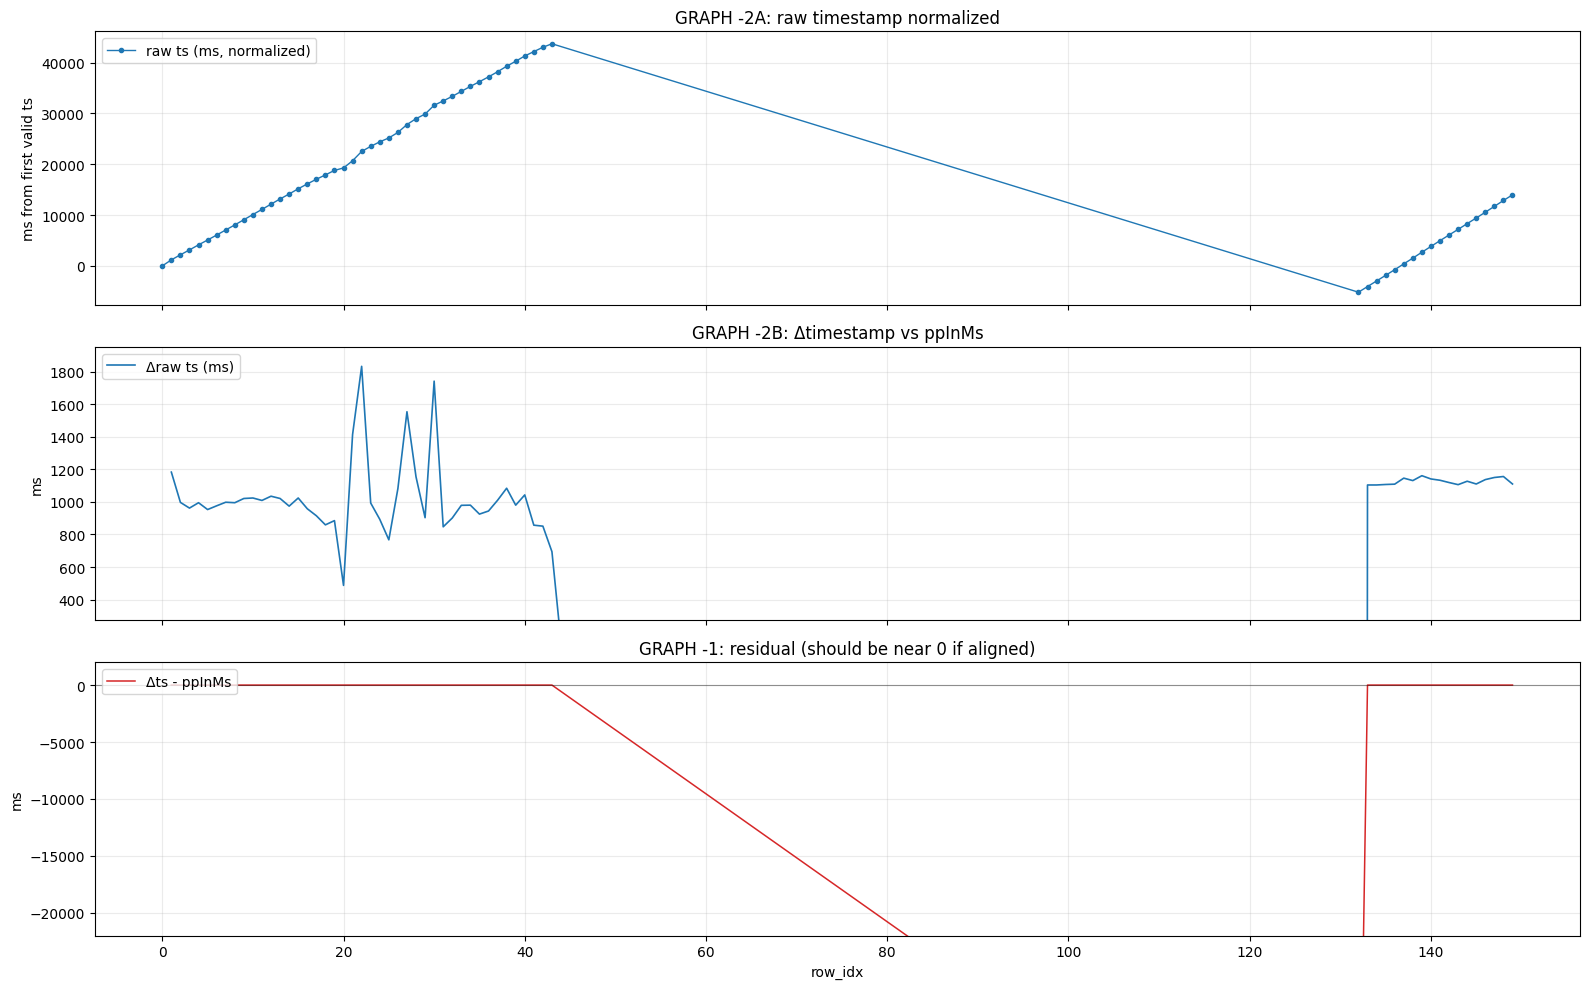

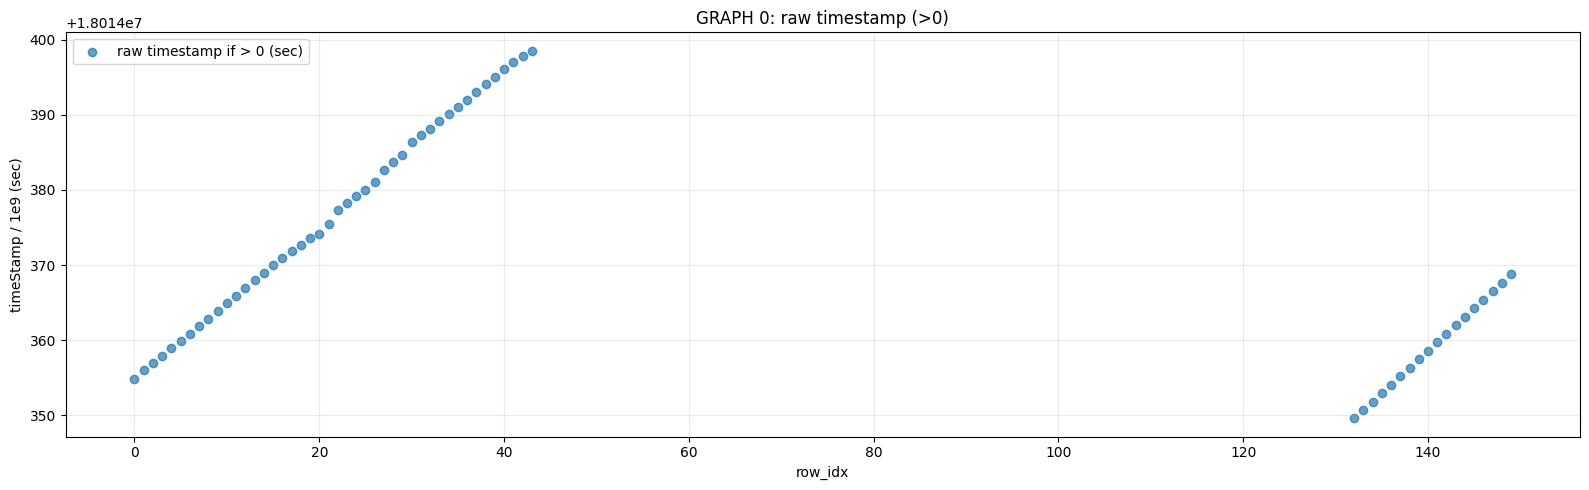

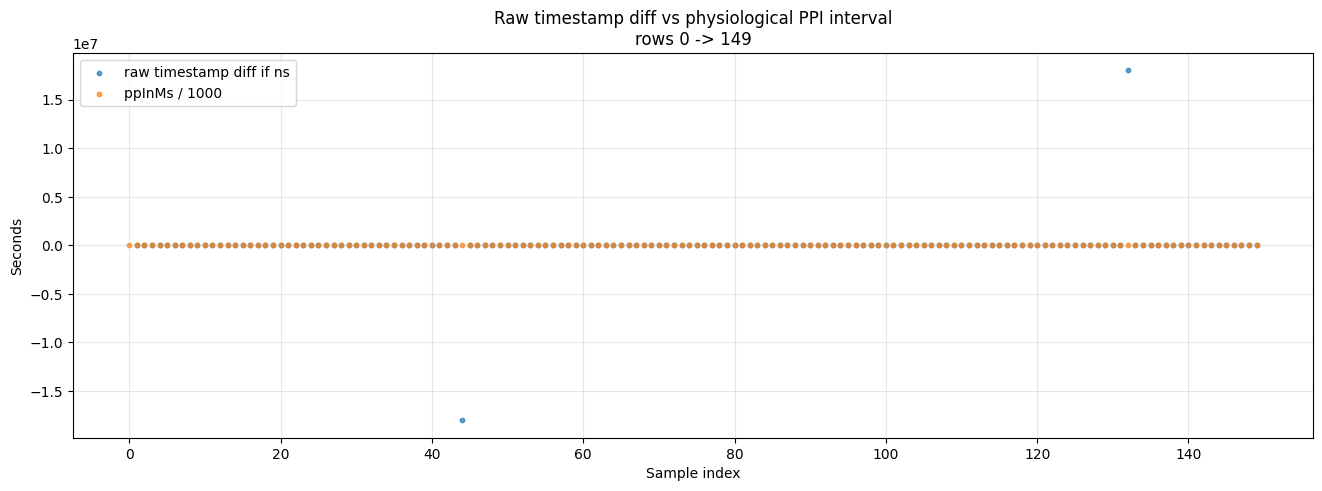

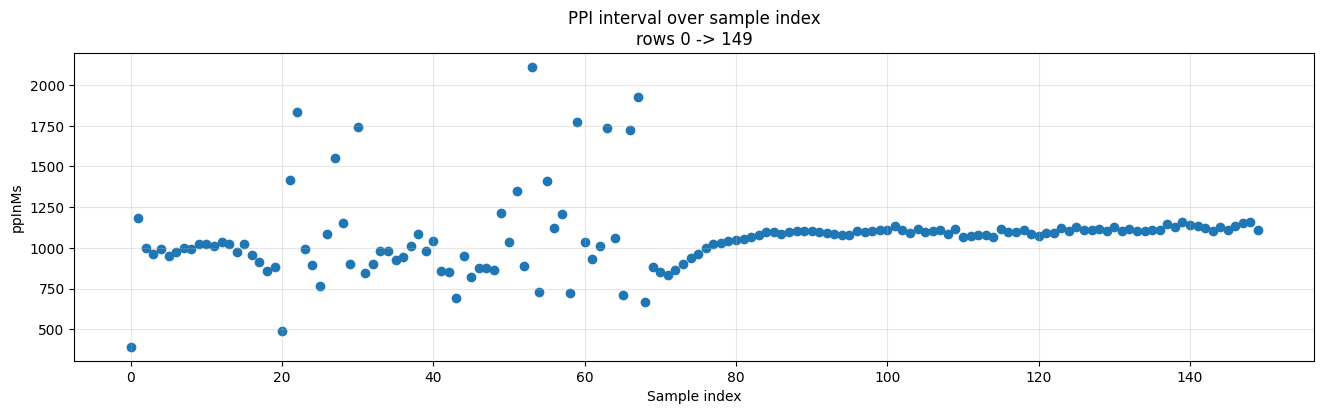

In [115]:
def plot_ppi_ts_debug(df: pd.DataFrame, skip: int = 0, take: int = 300):
    xdf = df.iloc[skip:skip + take].copy()
    if xdf.empty:
        print("Empty slice")
        return

    print(f"Showing rows: {skip} -> {skip + len(xdf) - 1}")

    # only valid ts
    tsv = xdf[xdf["timeStamp"] > 0].copy()
    if tsv.empty:
        print("No valid timeStamp > 0 in slice")
        return

    # to ms
    tsv["ts_ms"] = tsv["timeStamp"] / 1e6
    tsv["dts_ms"] = tsv["ts_ms"].diff()

    # align ppInMs on valid-ts rows
    tsv["ppInMs"] = tsv["ppInMs"].astype(float)

    # residual: якщо timestamp узгоджений з ppi, має бути близько 0
    tsv["residual_ms"] = tsv["dts_ms"] - tsv["ppInMs"]

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    # GRAPH -2A: normalized raw timestamp (відняли перше значення)
    axes[0].plot(
        tsv["row_idx"],
        tsv["ts_ms"] - tsv["ts_ms"].iloc[0],
        marker="o",
        ms=3,
        lw=1,
        label="raw ts (ms, normalized)"
    )
    axes[0].set_title("GRAPH -2A: raw timestamp normalized")
    axes[0].set_ylabel("ms from first valid ts")
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="upper left")

    # GRAPH -2B: dts vs ppInMs (одна шкала!)
    axes[1].plot(tsv["row_idx"], tsv["dts_ms"], lw=1.2, label="Δraw ts (ms)")
    # axes[1].plot(tsv["row_idx"], tsv["ppInMs"], lw=1.2, label="ppInMs")
    axes[1].axhline(0, color="black", lw=0.8, alpha=0.4)
    axes[1].set_title("GRAPH -2B: Δtimestamp vs ppInMs")
    axes[1].set_ylabel("ms")
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="upper left")

    # GRAPH -1: residual
    axes[2].plot(tsv["row_idx"], tsv["residual_ms"], lw=1.1, color="tab:red", label="Δts - ppInMs")
    axes[2].axhline(0, color="black", lw=0.8, alpha=0.4)
    axes[2].set_title("GRAPH -1: residual (should be near 0 if aligned)")
    axes[2].set_ylabel("ms")
    axes[2].set_xlabel("row_idx")
    axes[2].grid(alpha=0.25)
    axes[2].legend(loc="upper left")

    # robust y-limits for bottom 2 plots
    for ax, col in [(axes[1], ["dts_ms", "ppInMs"]), (axes[2], ["residual_ms"])]:
        vals = pd.concat([tsv[c].replace([np.inf, -np.inf], np.nan).dropna() for c in col])
        if not vals.empty:
            lo, hi = vals.quantile([0.01, 0.99])
            if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
                pad = 0.1 * (hi - lo)
                ax.set_ylim(lo - pad, hi + pad)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # GRAPH 0 (твій оригінальний, збережений)
    # ---------------------------------------------------
    plt.figure(figsize=(16, 5))
    plt.scatter(
        xdf[xdf["timeStamp"] > 0]["row_idx"],
        xdf[xdf["timeStamp"] > 0]["timeStamp"] / 1e9,
        label="raw timestamp if > 0 (sec)",
        alpha=0.7
    )
    plt.title("GRAPH 0: raw timestamp (>0)")
    plt.xlabel("row_idx")
    plt.ylabel("timeStamp / 1e9 (sec)")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # GRAPH 1
    # ---------------------------------------------------

    plt.figure(figsize=(16, 5))

    plt.scatter(
        xdf["row_idx"],
        xdf["timestamp_diff_s_if_ns"],
        label="raw timestamp diff if ns",
        s=10,
        alpha=0.7
    )

    plt.scatter(
        xdf["row_idx"],
        xdf["pp_s"],
        label="ppInMs / 1000",
        s=10,
        alpha=0.7
    )

    

    plt.title(
        f"Raw timestamp diff vs physiological PPI interval\n"
        f"rows {skip} -> {skip + len(xdf) - 1}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Seconds")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

    # ---------------------------------------------------
    # GRAPH 2
    # ---------------------------------------------------

    plt.figure(figsize=(16, 4))

    plt.scatter(
        xdf["row_idx"],
        xdf["ppInMs"],
        linewidth=1
    )

    plt.title(
        f"PPI interval over sample index\n"
        f"rows {skip} -> {skip + len(xdf) - 1}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("ppInMs")

    plt.grid(True, alpha=0.3)

    plt.show()
plot_ppi_ts_debug(df, skip=0, take=150)

# Strategy A — Anchor interpolation

Ця стратегія тестує твою ідею:

> знайти два timestamp-и, які реально виглядають валідно, і розподілити/усереднити час між ними.

Ми робимо це не тільки для двох точок, а для всіх знайдених “valid anchors”.
Якщо anchors мало або вони погані — стратегія автоматично стає другорядною.

In [116]:
def detect_timestamp_anchors(
    df: pd.DataFrame,
    min_step_s: float = 0.05,
    max_step_s: float = 10.0,
    allow_first_non_zero: bool = True,
) -> pd.DataFrame:
    out = df.copy()
    diff_s = out["timeStamp"].diff() / 1e9

    anchor = (
        out["timeStamp"].notna()
        & out["timeStamp"].ne(0)
        & diff_s.gt(min_step_s)
        & diff_s.le(max_step_s)
    )

    if allow_first_non_zero:
        idx = out.index[out["timeStamp"].notna() & out["timeStamp"].ne(0)]
        if len(idx):
            anchor.loc[idx[0]] = True

    out["is_timestamp_anchor"] = anchor
    out["anchor_diff_s"] = diff_s.where(anchor)
    return out


def build_anchor_interpolated_timeline(df: pd.DataFrame) -> pd.DataFrame:
    out = detect_timestamp_anchors(df).copy()
    anchors = out[out["is_timestamp_anchor"]].copy()

    out["t_anchor_interp_s"] = np.nan
    out["t_anchor_strategy_note"] = "fallback_cumulative_ppi"

    if len(anchors) >= 2:
        first_ts = anchors["timeStamp"].iloc[0]
        anchor_x = anchors["row_idx"].to_numpy()
        anchor_y = ((anchors["timeStamp"] - first_ts) / 1e9).to_numpy()

        in_range = out["row_idx"].between(anchor_x.min(), anchor_x.max())
        out.loc[in_range, "t_anchor_interp_s"] = np.interp(
            out.loc[in_range, "row_idx"],
            anchor_x,
            anchor_y
        )
        out.loc[in_range, "t_anchor_strategy_note"] = "interpolated_between_valid_anchors"

    elif len(anchors) == 1:
        i = anchors.index[0]
        out.loc[i, "t_anchor_interp_s"] = 0.0
        out.loc[i, "t_anchor_strategy_note"] = "single_anchor_only"

    # Fallback cumulative PPI for zones without anchors.
    pp_s = out["pp_s"].where(out["ppi_physio_plausible"])
    pp_s = pp_s.fillna(pp_s.median())
    fallback = pp_s.cumsum()
    fallback = fallback - fallback.iloc[0]

    has_interp = out["t_anchor_interp_s"].notna()
    if has_interp.any():
        first_i = out.index[has_interp][0]
        offset = out.loc[first_i, "t_anchor_interp_s"] - fallback.loc[first_i]
        fallback = fallback + offset

    out["t_anchor_interp_s"] = out["t_anchor_interp_s"].fillna(fallback)
    out["t_anchor_interp_min"] = out["t_anchor_interp_s"] / 60.0
    return out


df = build_anchor_interpolated_timeline(df)

print("Anchor count:", int(df["is_timestamp_anchor"].sum()))
display(df.loc[df["is_timestamp_anchor"], [
    "row_idx", "timeStamp", "timestamp_diff_s_if_ns", "ppInMs",
    "hr", "ppErrorEstimate", "blockerBit"
]].head(30))

Anchor count: 15567


,row_idx,timeStamp,timestamp_diff_s_if_ns,ppInMs,hr,ppErrorEstimate,blockerBit
0,0,18014354808481984,NaN,393,0,30,1
1,1,18014355991481984,1.183,1183,0,30,1
2,2,18014356988481984,0.997,997,0,30,1
3,3,18014357950481984,0.962,962,0,30,0
4,4,18014358945481984,0.995,995,0,30,1
5,5,18014359898481984,0.953,953,0,30,0
6,6,18014360874481984,0.976,976,0,30,0
7,7,18014361872481984,0.998,998,0,30,0
8,8,18014362867481984,0.995,995,0,25,0
9,9,18014363888481984,1.021,1021,0,20,0


# Strategy B — Cumulative PPI reconstruction

Це друга стратегія:

> взяти стартову точку і будувати час через накопичення `ppInMs`.

Для PPI це часто найстабільніший варіант, бо `ppInMs` сам по собі є інтервалом між ударами.

In [117]:
def build_cumulative_ppi_timeline(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    pp_s = out["pp_s"].where(out["ppi_physio_plausible"])
    pp_s = pp_s.fillna(pp_s.median())

    out["pp_s_for_reconstruction"] = pp_s
    out["t_ppi_reconstructed_s"] = pp_s.cumsum()
    out["t_ppi_reconstructed_s"] = out["t_ppi_reconstructed_s"] - out["t_ppi_reconstructed_s"].iloc[0]
    out["t_ppi_reconstructed_min"] = out["t_ppi_reconstructed_s"] / 60.0
    return out


df = build_cumulative_ppi_timeline(df)

raw_duration_s = (df["timeStamp"].max() - df["timeStamp"].min()) / 1e9
a_duration_s = df["t_anchor_interp_s"].max() - df["t_anchor_interp_s"].min()
b_duration_s = df["t_ppi_reconstructed_s"].max() - df["t_ppi_reconstructed_s"].min()

print(f"Raw duration if ns: {raw_duration_s:,.2f}s = {raw_duration_s/3600:,.2f}h")
print(f"Strategy A duration: {a_duration_s:,.2f}s = {a_duration_s/60:,.2f}min")
print(f"Strategy B duration: {b_duration_s:,.2f}s = {b_duration_s/60:,.2f}min")

display(df[[
    "row_idx", "timeStamp", "ppInMs",
    "t_anchor_interp_s", "t_ppi_reconstructed_s",
    "t_anchor_strategy_note"
]].head(20))

Raw duration if ns: 18,014,398.51s = 5,004.00h
Strategy A duration: 30,276.09s = 504.60min
Strategy B duration: 30,258.77s = 504.31min


,row_idx,timeStamp,ppInMs,t_anchor_interp_s,t_ppi_reconstructed_s,t_anchor_strategy_note
0,0,18014354808481984,393,0.000,0.000,interpolated_between_valid_anchors
1,1,18014355991481984,1183,1.183,1.183,interpolated_between_valid_anchors
2,2,18014356988481984,997,2.180,2.180,interpolated_between_valid_anchors
3,3,18014357950481984,962,3.142,3.142,interpolated_between_valid_anchors
4,4,18014358945481984,995,4.137,4.137,interpolated_between_valid_anchors
5,5,18014359898481984,953,5.090,5.090,interpolated_between_valid_anchors
6,6,18014360874481984,976,6.066,6.066,interpolated_between_valid_anchors
7,7,18014361872481984,998,7.064,7.064,interpolated_between_valid_anchors
8,8,18014362867481984,995,8.059,8.059,interpolated_between_valid_anchors
9,9,18014363888481984,1021,9.080,9.080,interpolated_between_valid_anchors


## 5. Compare both strategies

Тут найважливіше:

- якщо Strategy A і Strategy B сильно розходяться — raw timestamps не мають достатньо валідних anchors;
- якщо Strategy B дає фізіологічно реалістичну тривалість — її можна взяти як primary PPI timeline;
- Strategy A можна залишити як diagnostic/secondary alignment.

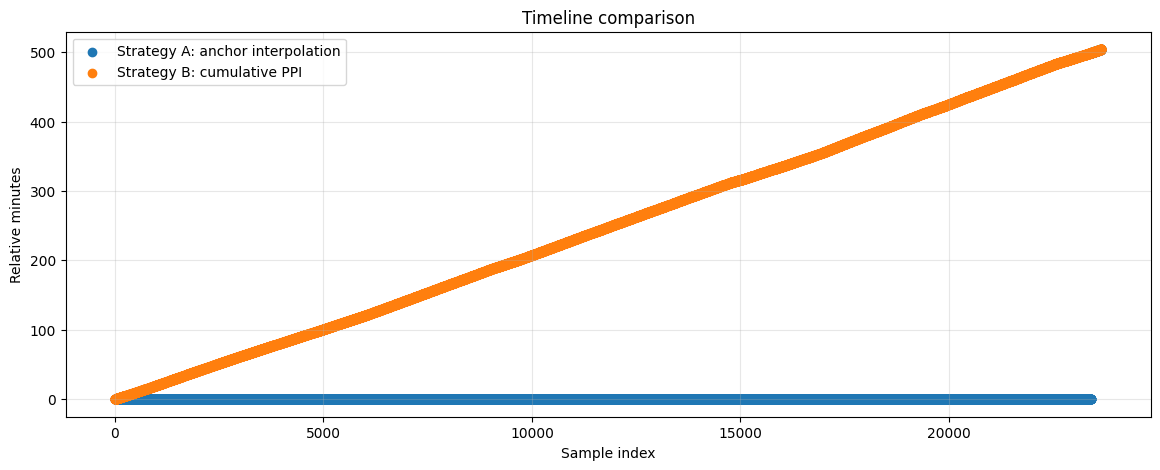

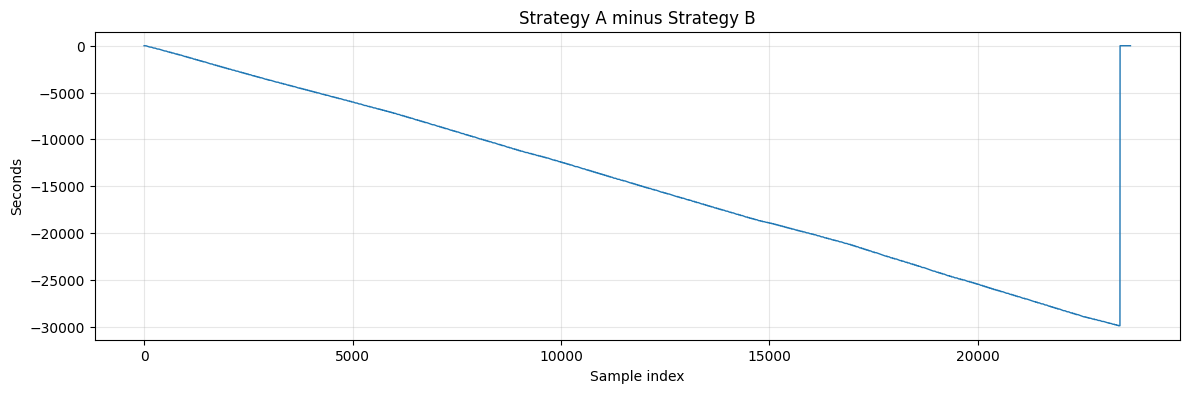

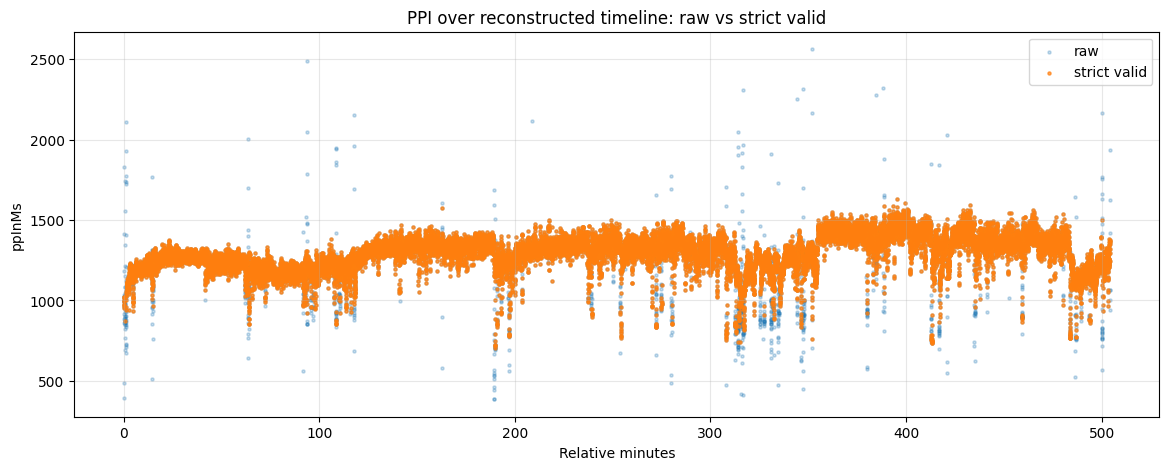

In [118]:
plt.figure(figsize=(14, 5))
plt.scatter(df["row_idx"], df["t_anchor_interp_min"], label="Strategy A: anchor interpolation", linewidth=1)
plt.scatter(df["row_idx"], df["t_ppi_reconstructed_min"], label="Strategy B: cumulative PPI", linewidth=1)
plt.title("Timeline comparison")
plt.xlabel("Sample index")
plt.ylabel("Relative minutes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["row_idx"], df["t_anchor_interp_s"] - df["t_ppi_reconstructed_s"], linewidth=1)
plt.title("Strategy A minus Strategy B")
plt.xlabel("Sample index")
plt.ylabel("Seconds")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.scatter(df["t_ppi_reconstructed_min"], df["ppInMs"], s=5, alpha=0.25, label="raw")
valid = df[df["valid_candidate_strict"]]
plt.scatter(valid["t_ppi_reconstructed_min"], valid["ppInMs"], s=5, alpha=0.7, label="strict valid")
plt.title("PPI over reconstructed timeline: raw vs strict valid")
plt.xlabel("Relative minutes")
plt.ylabel("ppInMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Timestamp quality taxonomy

Цю колонку варто потім перенести в normalizer/time alignment report.

,count
timestamp_quality_class,
okish_anchor_candidate,15566
zero_timestamp,7732
negative_timestamp,253
huge_jump,108
unknown_or_first_sample,1


,pct
timestamp_quality_class,
okish_anchor_candidate,65.790
zero_timestamp,32.680
negative_timestamp,1.069
huge_jump,0.456
unknown_or_first_sample,0.004


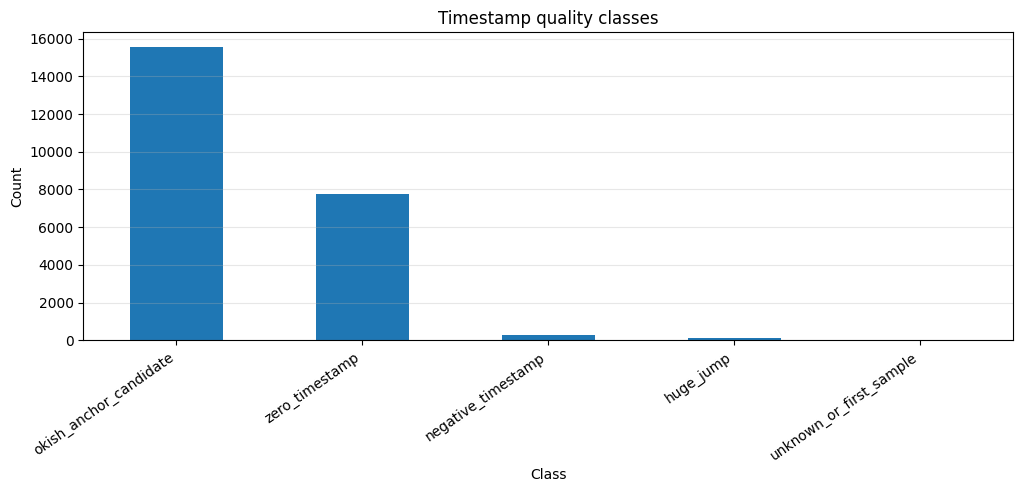

In [119]:
def classify_timestamp_quality(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    diff_s = out["timestamp_diff_s_if_ns"]

    conditions = [
        out["timeStamp"].eq(0),
        diff_s.eq(0),
        diff_s.lt(0),
        diff_s.gt(10),
        diff_s.between(0, 0.05, inclusive="neither"),
        diff_s.between(0.05, 10, inclusive="both"),
    ]
    choices = [
        "zero_timestamp",
        "duplicate_timestamp",
        "negative_timestamp",
        "huge_jump",
        "too_fast_for_beat_time",
        "okish_anchor_candidate",
    ]

    out["timestamp_quality_class"] = np.select(
        conditions,
        choices,
        default="unknown_or_first_sample"
    )
    return out


df = classify_timestamp_quality(df)

display(df["timestamp_quality_class"].value_counts(dropna=False).to_frame("count"))
display((100 * df["timestamp_quality_class"].value_counts(dropna=False) / len(df)).round(3).to_frame("pct"))

plt.figure(figsize=(12, 4))
df["timestamp_quality_class"].value_counts().plot(kind="bar")
plt.title("Timestamp quality classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 7. Filtering effect demonstration

Показуємо, як quality filtering прибирає blocker/outlier samples, але raw дані залишаються доступними.

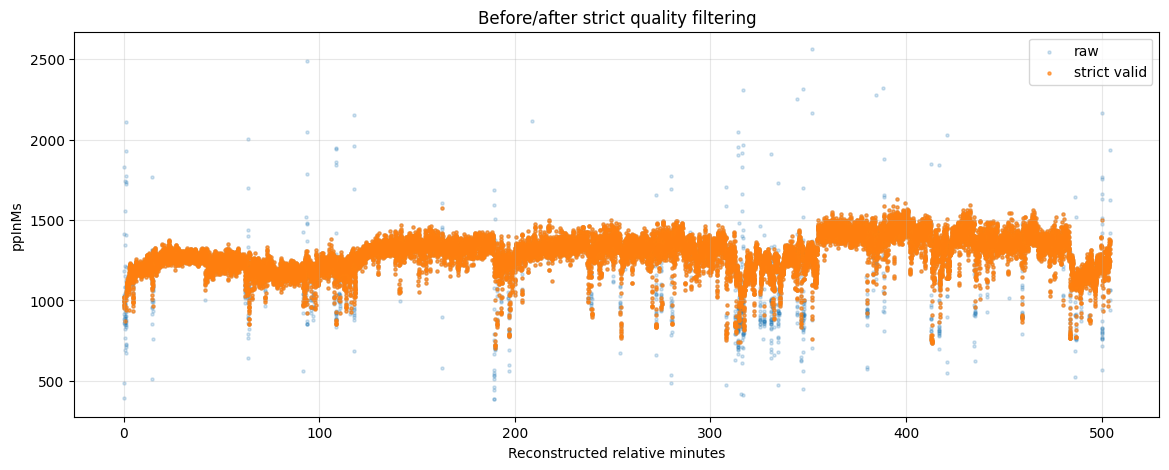

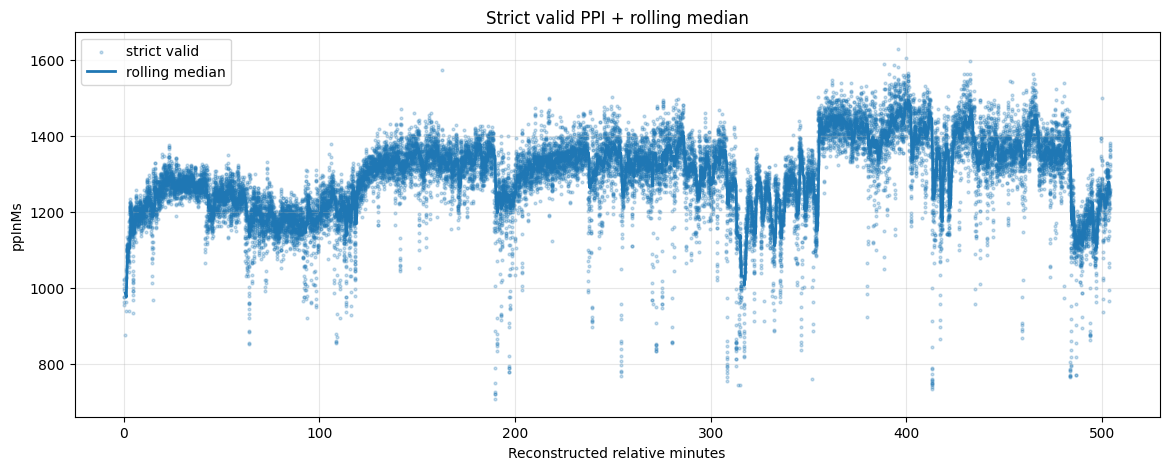

In [120]:
plt.figure(figsize=(14, 5))
plt.scatter(df["t_ppi_reconstructed_min"], df["ppInMs"], s=5, alpha=0.2, label="raw")
plt.scatter(valid["t_ppi_reconstructed_min"], valid["ppInMs"], s=5, alpha=0.65, label="strict valid")
plt.title("Before/after strict quality filtering")
plt.xlabel("Reconstructed relative minutes")
plt.ylabel("ppInMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

smooth = valid.set_index("t_ppi_reconstructed_s")["ppInMs"].rolling(window=60, min_periods=10).median()

plt.figure(figsize=(14, 5))
plt.scatter(valid["t_ppi_reconstructed_min"], valid["ppInMs"], s=4, alpha=0.25, label="strict valid")
plt.plot(smooth.index / 60.0, smooth.values, linewidth=2, label="rolling median")
plt.title("Strict valid PPI + rolling median")
plt.xlabel("Reconstructed relative minutes")
plt.ylabel("ppInMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. ML-oriented window features

Це підготовка до sleep/ML features:

- valid ratio
- median PPI
- mean HR
- SDNN
- RMSSD
- pNN50
- quality score
- blocker ratio
- pp error median

In [121]:
def rmssd_ms(pp_ms: pd.Series) -> float:
    x = pp_ms.dropna().to_numpy()
    if len(x) < 3:
        return np.nan
    return float(np.sqrt(np.mean(np.diff(x) ** 2)))

def sdnn_ms(pp_ms: pd.Series) -> float:
    x = pp_ms.dropna().to_numpy()
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1))

def pnn50(pp_ms: pd.Series) -> float:
    x = pp_ms.dropna().to_numpy()
    if len(x) < 3:
        return np.nan
    return float(np.mean(np.abs(np.diff(x)) > 50))

def build_window_features(df: pd.DataFrame, window_s: int) -> pd.DataFrame:
    x = df.copy()
    x["window_id"] = np.floor(x["t_ppi_reconstructed_s"] / window_s).astype(int)

    rows = []
    for wid, g in x.groupby("window_id", sort=True):
        valid_g = g[g["valid_candidate_strict"]]
        rows.append({
            "window_id": wid,
            "window_start_s": wid * window_s,
            "window_start_min": wid * window_s / 60,
            "window_s": window_s,
            "n_samples": len(g),
            "n_valid": len(valid_g),
            "valid_ratio": len(valid_g) / len(g) if len(g) else np.nan,
            "median_pp_ms": valid_g["ppInMs"].median(),
            "mean_pp_ms": valid_g["ppInMs"].mean(),
            "median_hr": valid_g["hr"].replace(0, np.nan).median(),
            "mean_hr": valid_g["hr"].replace(0, np.nan).mean(),
            "sdnn_ms": sdnn_ms(valid_g["ppInMs"]),
            "rmssd_ms": rmssd_ms(valid_g["ppInMs"]),
            "pnn50": pnn50(valid_g["ppInMs"]),
            "mean_quality_score": g["quality_score_0_1"].mean(),
            "blocker_ratio": 1 - g["not_blocked"].mean(),
            "pp_error_median": g["ppErrorEstimate"].median(),
            "contact_ratio": g["valid_contact"].mean(),
        })

    return pd.DataFrame(rows)

features_30s = build_window_features(df, 30)
features_60s = build_window_features(df, 60)
features_5m = build_window_features(df, 300)

display(features_30s.head())
display(features_30s.describe(percentiles=[0.05, 0.5, 0.95]).T)

,window_id,window_start_s,window_start_min,window_s,n_samples,n_valid,valid_ratio,median_pp_ms,mean_pp_ms,median_hr,mean_hr,sdnn_ms,rmssd_ms,pnn50,mean_quality_score,blocker_ratio,pp_error_median,contact_ratio
0,0,0,0.0,30,30,9,0.300000,995.0,990.222222,NaN,NaN,25.425272,20.118400,0.0,0.652900,0.700000,30.0,1.0
1,1,30,0.5,30,29,1,0.034483,874.0,874.000000,NaN,NaN,NaN,NaN,NaN,0.593655,0.931034,36.0,1.0
2,2,60,1.0,30,27,12,0.444444,1047.0,1037.083333,56.0,56.545455,49.798610,18.278154,0.0,0.734667,0.296296,46.0,1.0
3,3,90,1.5,30,28,28,1.000000,1098.0,1096.714286,55.0,54.678571,15.136067,15.861671,0.0,0.971821,0.000000,9.0,1.0
4,4,120,2.0,30,27,27,1.000000,1108.0,1109.740741,54.0,53.962963,20.783856,19.544820,0.0,0.972111,0.000000,9.0,1.0


,count,mean,std,min,5%,50%,95%,max
window_id,1009.0,504.000000,291.417513,0.000000,50.400000,504.000000,957.600000,1008.000000
window_start_s,1009.0,15120.000000,8742.525379,0.000000,1512.000000,15120.000000,28728.000000,30240.000000
window_start_min,1009.0,252.000000,145.708756,0.000000,25.200000,252.000000,478.800000,504.000000
window_s,1009.0,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
n_samples,1009.0,23.448959,2.083005,15.000000,21.000000,23.000000,27.000000,35.000000
n_valid,1009.0,22.454906,2.974795,0.000000,17.400000,23.000000,26.000000,29.000000
valid_ratio,1009.0,0.963852,0.127523,0.000000,0.652174,1.000000,1.000000,1.000000
median_pp_ms,1008.0,1295.388393,96.763854,810.500000,1142.525000,1313.750000,1437.000000,1520.000000
mean_pp_ms,1008.0,1291.680985,97.833467,855.375000,1130.227000,1310.911067,1431.395238,1521.052632
median_hr,1006.0,46.498012,3.615197,30.000000,42.000000,46.000000,52.000000,73.000000


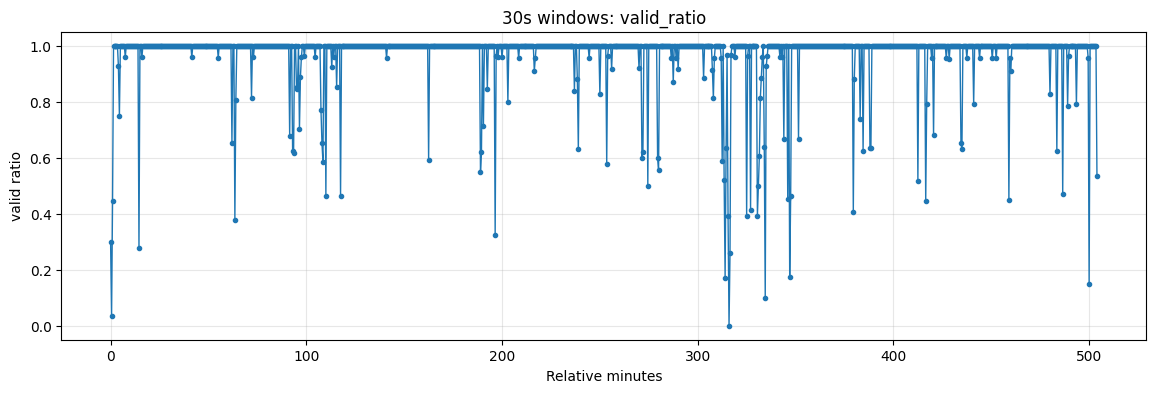

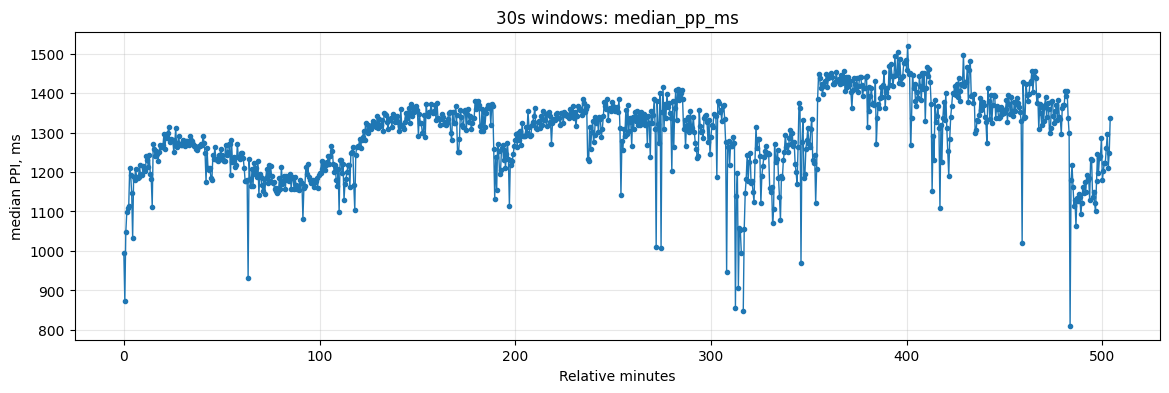

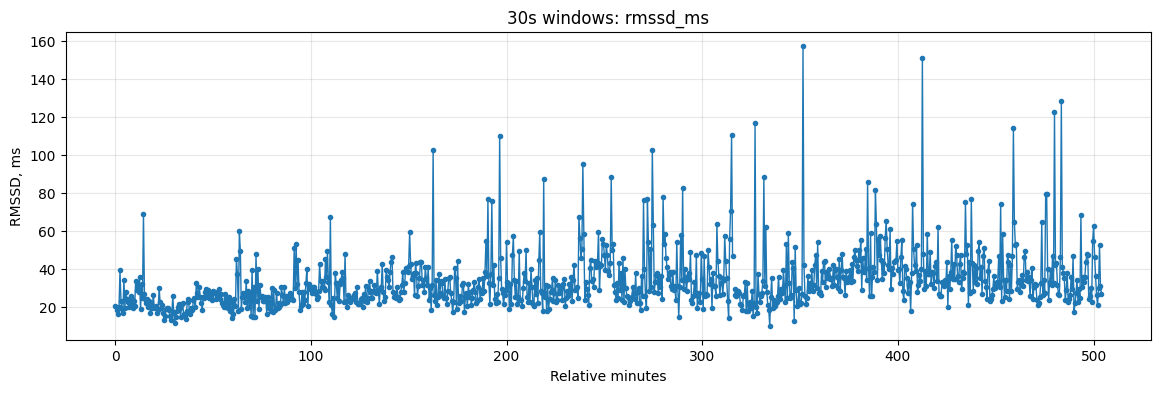

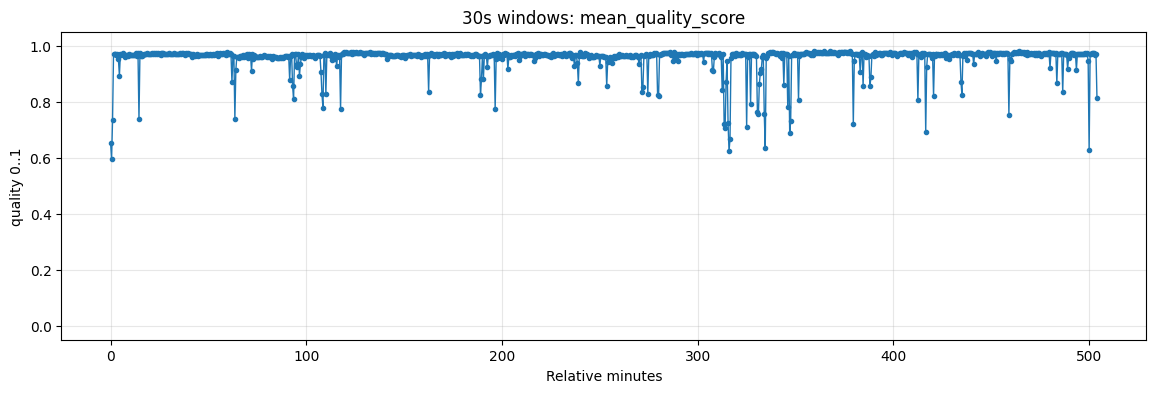

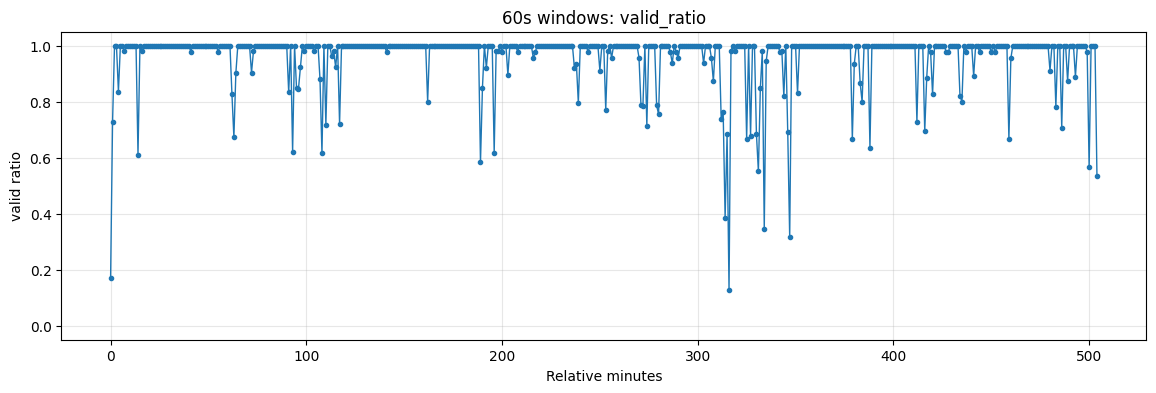

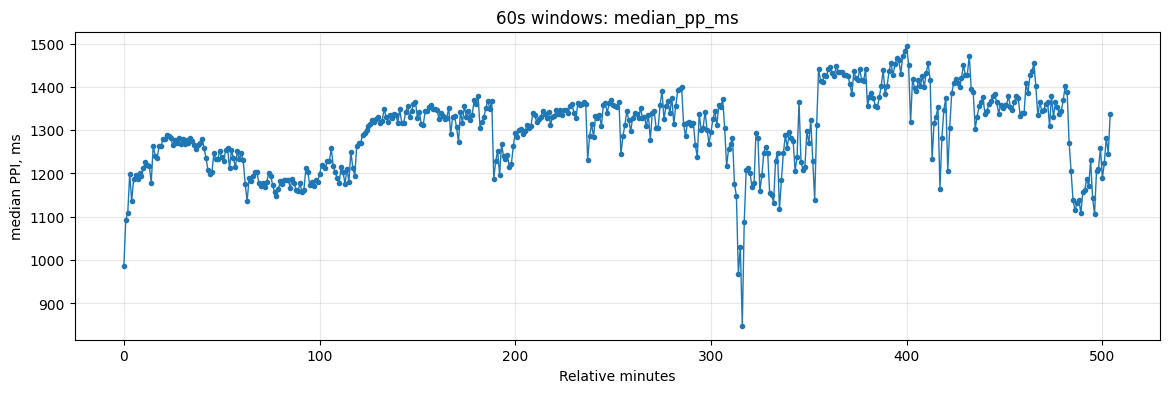

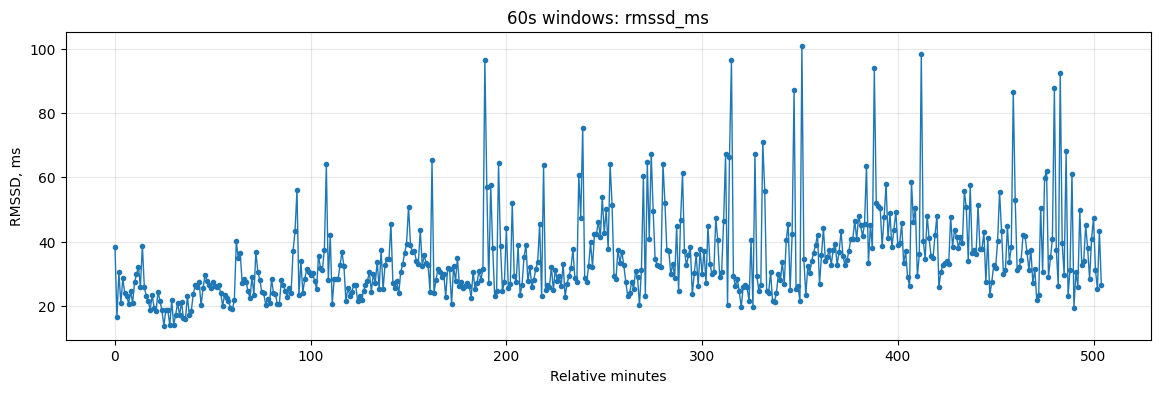

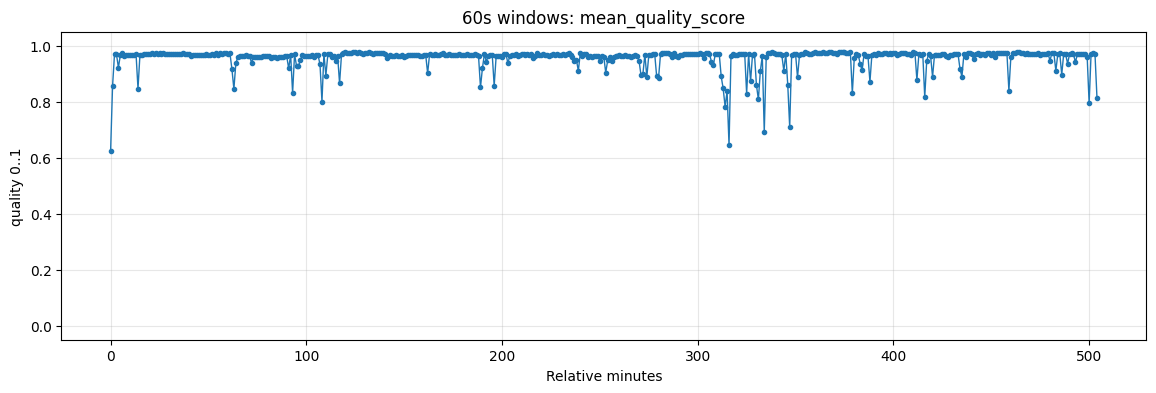

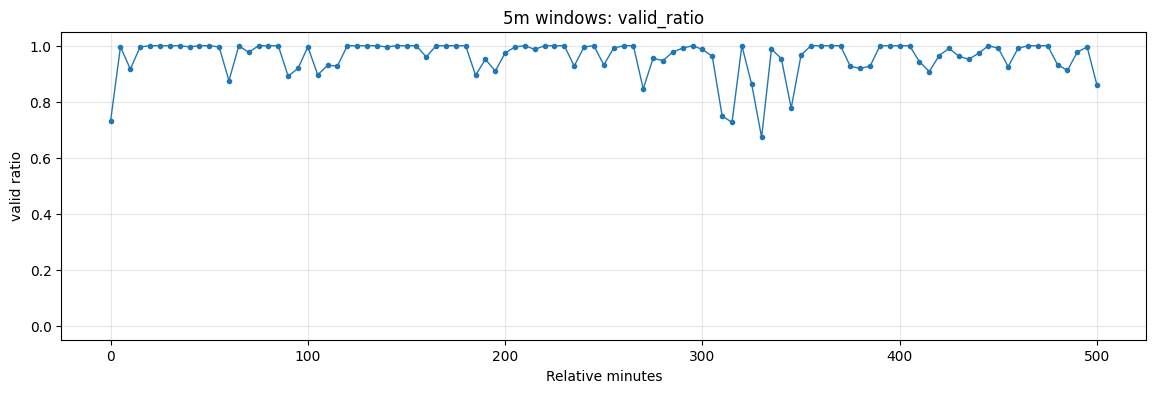

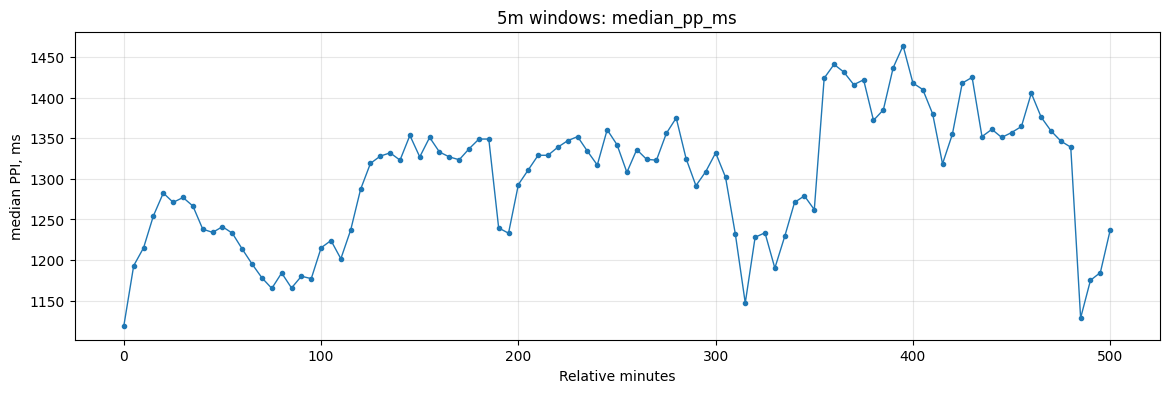

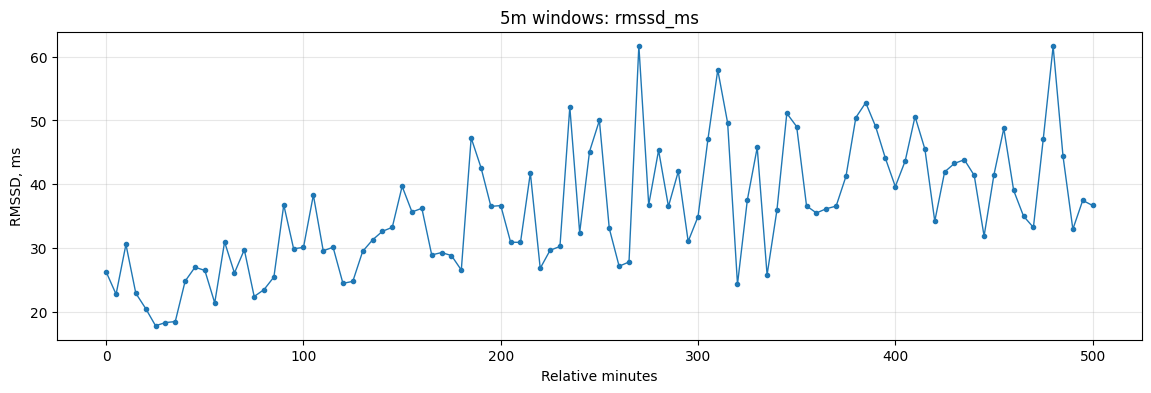

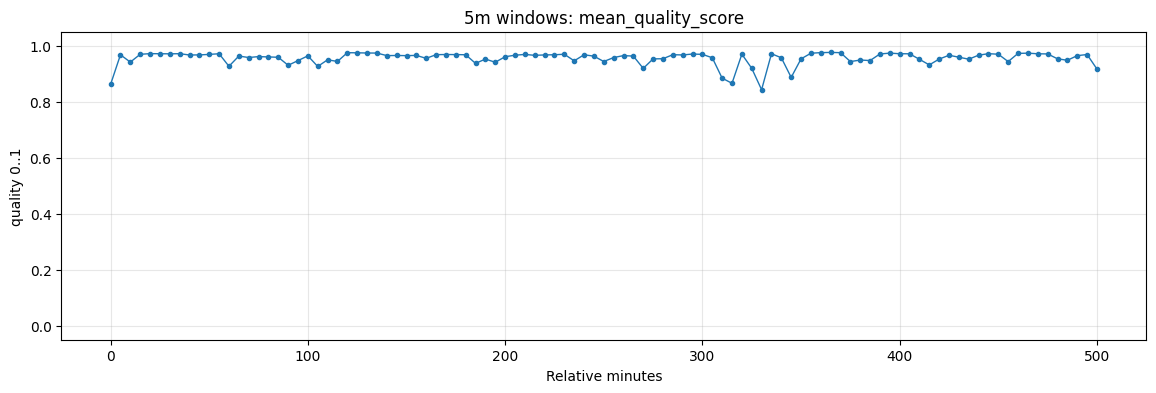

In [122]:
def plot_window_features(features: pd.DataFrame, title: str):
    for col, ylabel in [
        ("valid_ratio", "valid ratio"),
        ("median_pp_ms", "median PPI, ms"),
        ("rmssd_ms", "RMSSD, ms"),
        ("mean_quality_score", "quality 0..1"),
    ]:
        plt.figure(figsize=(14, 4))
        plt.plot(features["window_start_min"], features[col], marker=".", linewidth=1)
        plt.title(f"{title}: {col}")
        plt.xlabel("Relative minutes")
        plt.ylabel(ylabel)
        if col in ["valid_ratio", "mean_quality_score"]:
            plt.ylim(-0.05, 1.05)
        plt.grid(True, alpha=0.3)
        plt.show()

plot_window_features(features_30s, "30s windows")
plot_window_features(features_60s, "60s windows")
plot_window_features(features_5m, "5m windows")

## 9. Decision report

Це summary можна використати як основу для `time_alignment_report.json`.

In [123]:
def make_decision_report(df: pd.DataFrame) -> dict:
    raw_duration_s = float((df["timeStamp"].max() - df["timeStamp"].min()) / 1e9)
    a_duration_s = float(df["t_anchor_interp_s"].max() - df["t_anchor_interp_s"].min())
    b_duration_s = float(df["t_ppi_reconstructed_s"].max() - df["t_ppi_reconstructed_s"].min())

    return {
        "sample_count": int(len(df)),
        "raw_timestamp": {
            "monotonic_non_decreasing": bool(df["timeStamp"].is_monotonic_increasing),
            "duplicate_count": int(df["timeStamp"].duplicated().sum()),
            "duplicate_ratio": float(df["timeStamp"].duplicated().mean()),
            "zero_count": int(df["timeStamp"].eq(0).sum()),
            "zero_ratio": float(df["timeStamp"].eq(0).mean()),
            "duration_if_ns_seconds": raw_duration_s,
            "usable_as_primary_beat_time": False,
        },
        "strategy_a_anchor_interpolation": {
            "anchor_count": int(df["is_timestamp_anchor"].sum()),
            "duration_seconds": a_duration_s,
            "duration_minutes": a_duration_s / 60,
            "recommended_role": "secondary_diagnostic",
        },
        "strategy_b_cumulative_ppi": {
            "duration_seconds": b_duration_s,
            "duration_minutes": b_duration_s / 60,
            "recommended_role": "primary_ppi_beat_timeline",
        },
        "quality": {
            "valid_candidate_strict_ratio": float(df["valid_candidate_strict"].mean()),
            "valid_candidate_relaxed_ratio": float(df["valid_candidate_relaxed"].mean()),
            "blocker_ratio": float((~df["not_blocked"]).mean()),
            "pp_error_median": float(df["ppErrorEstimate"].median()),
            "skin_contact_ratio": float(df["valid_contact"].mean()),
        },
        "normalizer_recommendation": {
            "preserve_raw_timeStamp": True,
            "add_t_ppi_reconstructed_s": True,
            "add_t_anchor_interp_s_as_diagnostic": True,
            "add_timestamp_quality_class": True,
            "add_quality_score_0_1": True,
            "add_valid_candidate_flags": True,
        },
    }

decision_report = make_decision_report(df)
print(json.dumps(decision_report, indent=2))

{
  "sample_count": 23660,
  "raw_timestamp": {
    "monotonic_non_decreasing": false,
    "duplicate_count": 10181,
    "duplicate_ratio": 0.43030431107354183,
    "zero_count": 7732,
    "zero_ratio": 0.3267962806424345,
    "duration_if_ns_seconds": 18014398.509481985,
    "usable_as_primary_beat_time": false
  },
  "strategy_a_anchor_interpolation": {
    "anchor_count": 15567,
    "duration_seconds": 30276.08500000023,
    "duration_minutes": 504.60141666667045,
    "recommended_role": "secondary_diagnostic"
  },
  "strategy_b_cumulative_ppi": {
    "duration_seconds": 30258.76500000023,
    "duration_minutes": 504.3127500000038,
    "recommended_role": "primary_ppi_beat_timeline"
  },
  "quality": {
    "valid_candidate_strict_ratio": 0.957607776838546,
    "valid_candidate_relaxed_ratio": 0.9618343195266272,
    "blocker_ratio": 0.03647506339814032,
    "pp_error_median": 10.0,
    "skin_contact_ratio": 1.0
  },
  "normalizer_recommendation": {
    "preserve_raw_timeStamp": true

## 10. Export debug artifacts

Це створить локальну папку поруч з notebook runtime:

- `ppi_time_aligned_debug.csv`
- `ppi_features_30s.csv`
- `ppi_features_60s.csv`
- `ppi_features_5m.csv`
- `ppi_time_alignment_report.json`

Raw `chunks.jsonl` не змінюється.

In [124]:
EXPORT_DIR = Path("./ppi_time_alignment_debug_outputs")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

debug_cols = [
    "row_idx", "line_no", "sample_idx_in_chunk", "sequence",
    "timeStamp", "timestamp_diff_raw", "timestamp_diff_s_if_ns", "timestamp_quality_class",
    "is_timestamp_anchor", "t_anchor_interp_s", "t_anchor_interp_min",
    "t_ppi_reconstructed_s", "t_ppi_reconstructed_min",
    "ppInMs", "pp_s", "hr", "ppErrorEstimate", "blockerBit",
    "skinContactSupported", "skinContactStatus",
    "valid_contact", "not_blocked", "pp_error_ok_strict", "pp_error_ok_relaxed",
    "ppi_physio_plausible", "valid_candidate_strict", "valid_candidate_relaxed",
    "quality_score_0_1",
]
debug_df = df[[c for c in debug_cols if c in df.columns]].copy()

debug_df.to_csv(EXPORT_DIR / "ppi_time_aligned_debug.csv", index=False)
features_30s.to_csv(EXPORT_DIR / "ppi_features_30s.csv", index=False)
features_60s.to_csv(EXPORT_DIR / "ppi_features_60s.csv", index=False)
features_5m.to_csv(EXPORT_DIR / "ppi_features_5m.csv", index=False)

with (EXPORT_DIR / "ppi_time_alignment_report.json").open("w", encoding="utf-8") as f:
    json.dump(decision_report, f, indent=2)

print("Exported to:", EXPORT_DIR.resolve())

Exported to: /Users/maksymponomarenko/Documents/homelab/notebooks/ppi_time_alignment_debug_outputs


# Practical conclusion

Після запуску notebook:

- Якщо raw timestamp duration абсурдний — не використовуй `timeStamp` як primary beat time.
- Якщо anchors мало або Strategy A сильно розходиться зі Strategy B — anchor interpolation лишити як diagnostic.
- Якщо cumulative PPI duration виглядає реалістично — брати Strategy B як primary PPI timeline.
- Для CP14 normalizer:
  - preserve raw `timeStamp`
  - add `t_ppi_reconstructed_s`
  - add `timestamp_quality_class`
  - add `quality_score_0_1`
  - add `valid_candidate_*`
  - emit `time_alignment_report.json`

## Session window fit checks (normalized PPI vs session bounds)

Цей блок перевіряє, чи reconstructed PPI timeline лягає в рамки сесії,
і як змінюється похибка при різних startup delay.


In [125]:
import pandas as pd
import numpy as np

def load_chunks_jsonl(path: Path):
    chunks_local = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            chunks_local.append(json.loads(line))
    return chunks_local

def _parse_ts_safe(x):
    ts = pd.to_datetime(x, utc=True, errors='coerce')
    return None if pd.isna(ts) else ts

def audit_time_hints(chunks_local):
    rows=[]
    for i, ch in enumerate(chunks_local):
        t = ch.get('time') or {}
        rec_start = _parse_ts_safe(t.get('recording_start_utc'))
        rec_end = _parse_ts_safe(t.get('recording_end_utc'))
        col_start = _parse_ts_safe(t.get('fetch_started_at_collector') or t.get('first_sample_received_at_collector'))
        col_end = _parse_ts_safe(t.get('fetch_completed_at_collector') or t.get('uploaded_at_collector'))

        rows.append({
            'chunk_idx': i,
            'sequence': ch.get('sequence'),
            'recording_start_utc': rec_start,
            'recording_end_utc': rec_end,
            'collector_start_utc': col_start,
            'collector_end_utc': col_end,
        })

    out = pd.DataFrame(rows)
    if len(out):
        for a,b,col in [
            ('recording_start_utc','recording_end_utc','recording_dur_s'),
            ('collector_start_utc','collector_end_utc','collector_dur_s'),
        ]:
            out[col] = (out[b] - out[a]).dt.total_seconds()
    return out

def _plausible_window(start, end, max_hours=48):
    if start is None or end is None:
        return False
    if end < start:
        return False
    return float((end - start).total_seconds()) <= max_hours * 3600

def _best_pair_by_expected_duration(starts, ends, expected_s):
    starts=[x for x in starts if x is not None]
    ends=[x for x in ends if x is not None]
    if not starts or not ends:
        return None, None, None

    candidates=[]
    for s in starts:
        for e in ends:
            if e < s:
                continue
            dur = float((e - s).total_seconds())
            if dur <= 0:
                continue
            err = abs(dur - expected_s) if expected_s is not None else dur
            candidates.append((err, dur, s, e))

    if not candidates:
        return None, None, None

    candidates.sort(key=lambda x: x[0])
    err, dur, s, e = candidates[0]
    return s, e, {'err_s': err, 'dur_s': dur}

def select_session_bounds(chunks_local, expected_duration_s=None):
    tdf = audit_time_hints(chunks_local)

    rec_starts = tdf['recording_start_utc'].dropna().tolist() if 'recording_start_utc' in tdf else []
    rec_ends = tdf['recording_end_utc'].dropna().tolist() if 'recording_end_utc' in tdf else []
    col_starts = tdf['collector_start_utc'].dropna().tolist() if 'collector_start_utc' in tdf else []
    col_ends = tdf['collector_end_utc'].dropna().tolist() if 'collector_end_utc' in tdf else []

    # 1) Prefer recording window only if plausible and near expected duration.
    rs, re, rmeta = _best_pair_by_expected_duration(rec_starts, rec_ends, expected_duration_s)
    if _plausible_window(rs, re):
        return rs, re, 'recording_start_end', tdf, rmeta

    # 2) Collector/upload window by expected duration match.
    cs, ce, cmeta = _best_pair_by_expected_duration(col_starts, col_ends, expected_duration_s)
    if _plausible_window(cs, ce):
        return cs, ce, 'collector_upload_bounds', tdf, cmeta

    # 3) If no plausible pair, still prefer collector pair closest to expected duration.
    if cs is not None and ce is not None:
        return cs, ce, 'collector_closest_to_expected_unchecked', tdf, cmeta

    return None, None, 'missing', tdf, None

def build_reconstructed_timeline_with_delay(df_in, startup_delay_s=25.0):
    out = df_in.copy().reset_index(drop=True)
    out['ppInMs'] = pd.to_numeric(out['ppInMs'], errors='coerce')
    out['pp_s'] = (out['ppInMs'].clip(lower=0) / 1000.0).fillna(0.0)
    out['t_reconstructed_s'] = out['pp_s'].shift(fill_value=0).cumsum() + float(startup_delay_s)

    if 'quality_score_0_1' in out.columns:
        out['quality_tier'] = pd.cut(
            out['quality_score_0_1'].fillna(0),
            bins=[-1, 0.50, 0.80, 1.01],
            labels=['low', 'medium', 'high']
        ).astype(str)
    else:
        out['quality_tier'] = 'unknown'

    return out

if 'chunks' not in globals():
    chunks = load_chunks_jsonl(RAW_JSONL_PATH)

expected_duration_s = float(pd.to_numeric(df['ppInMs'], errors='coerce').clip(lower=0).fillna(0).sum() / 1000.0)
session_start, session_end, session_bounds_source, time_hints_df, bounds_meta = select_session_bounds(
    chunks_local=chunks,
    expected_duration_s=expected_duration_s,
)

print('session_bounds_source:', session_bounds_source)
print('session_start       :', session_start)
print('session_end         :', session_end)
print('expected_duration_s :', round(expected_duration_s, 3))
print('bounds_meta         :', bounds_meta)
display(time_hints_df.head(20))


session_bounds_source: recording_start_end
session_start       : 2017-07-19 07:48:45+00:00
session_end         : 2017-07-19 16:13:10.002000+00:00
expected_duration_s : 30266.627
bounds_meta         : {'err_s': 1.625, 'dur_s': 30265.002}


,chunk_idx,sequence,recording_start_utc,recording_end_utc,collector_start_utc,collector_end_utc,recording_dur_s,collector_dur_s
0,0,1,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2026-05-06 07:13:52.121000+00:00,2026-05-06 07:14:34.528000+00:00,30265.002,42.407


In [126]:
delay_grid = [0, 10, 15, 20, 25, 30, 35, 40]
rows=[]
for d in delay_grid:
    recon = build_reconstructed_timeline_with_delay(df, startup_delay_s=d)
    total_s = float(recon['pp_s'].sum())
    if session_start is not None:
        recon_start = session_start + pd.to_timedelta(d, unit='s')
        recon_last = recon_start + pd.to_timedelta(float(recon['t_reconstructed_s'].iloc[-1]), unit='s')
    else:
        recon_start = None
        recon_last = None
    end_delta_s = None
    if recon_last is not None and session_end is not None:
        end_delta_s = float((recon_last - session_end).total_seconds())
    rows.append({
        'startup_delay_s': d,
        'session_start': session_start,
        'session_end': session_end,
        'recon_start': recon_start,
        'recon_last': recon_last,
        'recon_total_pp_s': total_s,
        'end_delta_s_recon_minus_session_end': end_delta_s,
        'abs_end_delta_s': abs(end_delta_s) if end_delta_s is not None else None,
    })

fit_df = pd.DataFrame(rows).sort_values('startup_delay_s').reset_index(drop=True)
display(fit_df)

best_delay_s = 25.0
if fit_df['abs_end_delta_s'].notna().any():
    best = fit_df.loc[fit_df['abs_end_delta_s'].idxmin()]
    best_delay_s = float(best['startup_delay_s'])
    print('Best delay by end alignment:')
    print(best[['startup_delay_s','end_delta_s_recon_minus_session_end','abs_end_delta_s']])
else:
    print('No session_end hint, using default best_delay_s=25.0')


# Build preferred end anchor for problematic-clock sessions
session_end_preferred = None
session_end_metadata_trusted = None
session_end_delta_s = None
if session_start is not None and len(df):
    recon_best = build_reconstructed_timeline_with_delay(df, startup_delay_s=best_delay_s)
    session_end_preferred = session_start + pd.to_timedelta(float(recon_best['t_reconstructed_s'].iloc[-1]), unit='s')
    if session_end is not None:
        session_end_delta_s = float((session_end - session_end_preferred).total_seconds())
        session_end_metadata_trusted = abs(session_end_delta_s) <= 60.0
    else:
        session_end_metadata_trusted = False

print('session_end_preferred        :', session_end_preferred)
print('session_end_metadata_trusted :', session_end_metadata_trusted)
print('session_end_delta_s(meta-pref):', session_end_delta_s)


,startup_delay_s,session_start,session_end,recon_start,recon_last,recon_total_pp_s,end_delta_s_recon_minus_session_end,abs_end_delta_s
0,0,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,30266.627,0.0,0.0
1,10,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:48:55+00:00,2017-07-19 16:13:30.002000+00:00,30266.627,20.0,20.0
2,15,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:49:00+00:00,2017-07-19 16:13:40.002000+00:00,30266.627,30.0,30.0
3,20,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:49:05+00:00,2017-07-19 16:13:50.002000+00:00,30266.627,40.0,40.0
4,25,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:49:10+00:00,2017-07-19 16:14:00.002000+00:00,30266.627,50.0,50.0
5,30,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:49:15+00:00,2017-07-19 16:14:10.002000+00:00,30266.627,60.0,60.0
6,35,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:49:20+00:00,2017-07-19 16:14:20.002000+00:00,30266.627,70.0,70.0
7,40,2017-07-19 07:48:45+00:00,2017-07-19 16:13:10.002000+00:00,2017-07-19 07:49:25+00:00,2017-07-19 16:14:30.002000+00:00,30266.627,80.0,80.0


Best delay by end alignment:
startup_delay_s                          0
end_delta_s_recon_minus_session_end    0.0
abs_end_delta_s                        0.0
Name: 0, dtype: object
session_end_preferred        : 2017-07-19 16:13:10.002000+00:00
session_end_metadata_trusted : True
session_end_delta_s(meta-pref): 0.0


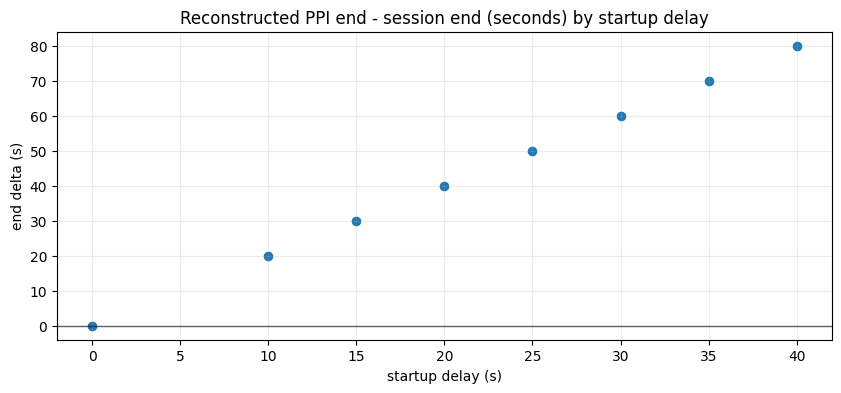

In [127]:
# Quick visual: end alignment error vs startup delay
import matplotlib.pyplot as plt
plot_df = fit_df[fit_df['end_delta_s_recon_minus_session_end'].notna()].copy()
if len(plot_df):
    plt.figure(figsize=(10,4))
    plt.scatter(plot_df['startup_delay_s'], plot_df['end_delta_s_recon_minus_session_end'], s=35)
    plt.axhline(0, color='black', lw=1, alpha=0.6)
    plt.title('Reconstructed PPI end - session end (seconds) by startup delay')
    plt.xlabel('startup delay (s)')
    plt.ylabel('end delta (s)')
    plt.grid(alpha=0.25)
    plt.show()
else:
    print('No session end hints available for delta plot')


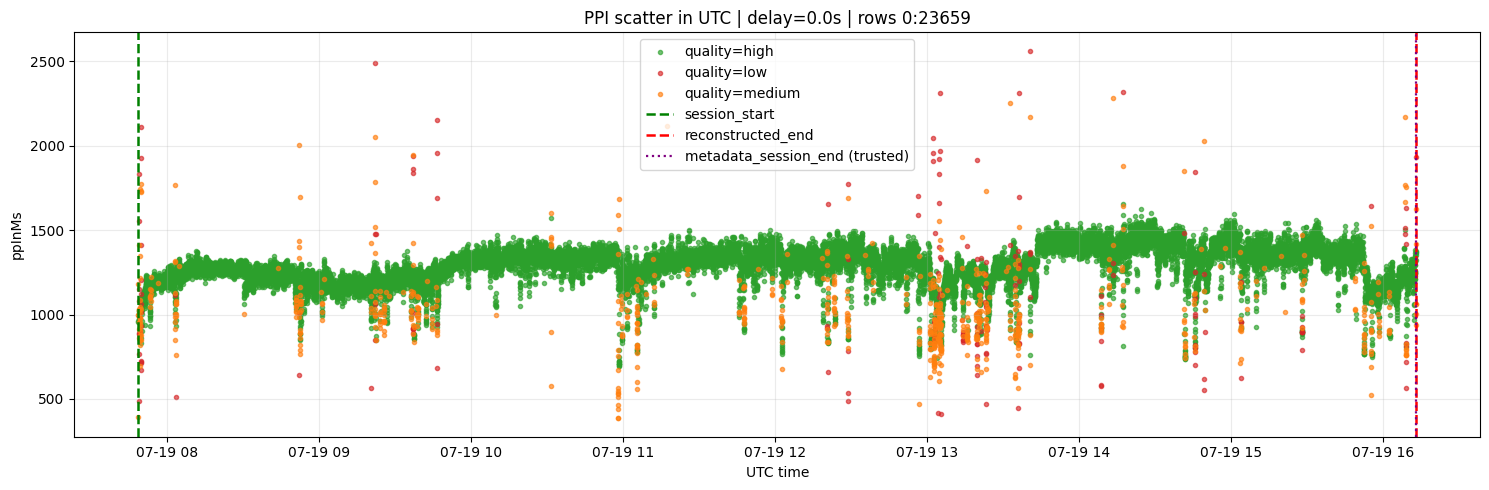

reconstructed_end           : 2017-07-19 16:13:10.002000+00:00
metadata_session_end        : 2017-07-19 16:13:10.002000+00:00
metadata_end_trusted        : True
metadata_end_delta_s        : 0.0


In [134]:
# Absolute UTC scatter with session anchors and skip/take windowing
import matplotlib.pyplot as plt

def plot_ppi_absolute_scatter(
    df_in: pd.DataFrame,
    session_start: pd.Timestamp,
    session_end: pd.Timestamp | None = None,
    startup_delay_s: float = 25.0,
    skip: int = 0,
    take: int = 3000,
    color_by: str = 'quality_tier',
    end_trust_threshold_s: float = 60.0,
):
    if session_start is None:
        raise RuntimeError('session_start is missing')

    recon = build_reconstructed_timeline_with_delay(df_in, startup_delay_s=startup_delay_s).copy()
    recon['t_abs_utc'] = session_start + pd.to_timedelta(recon['t_reconstructed_s'], unit='s')

    # Preferred end anchor from reconstructed PPI timeline (same time domain as points).
    reconstructed_end = recon['t_abs_utc'].iloc[-1] if len(recon) else None

    # Metadata session_end trust check
    metadata_end_trusted = None
    metadata_end_delta_s = None
    if session_end is not None and reconstructed_end is not None:
        metadata_end_delta_s = float((session_end - reconstructed_end).total_seconds())
        metadata_end_trusted = abs(metadata_end_delta_s) <= float(end_trust_threshold_s)

    xdf = recon.iloc[skip:skip+take].copy()
    if xdf.empty:
        print('Empty slice')
        return xdf

    plt.figure(figsize=(15,5))

    if color_by == 'strict_valid' and 'valid_candidate_strict' in xdf.columns:
        bad = xdf[~xdf['valid_candidate_strict']]
        good = xdf[xdf['valid_candidate_strict']]
        plt.scatter(bad['t_abs_utc'], bad['ppInMs'], s=7, alpha=0.20, color='tab:blue', label='raw / not strict')
        plt.scatter(good['t_abs_utc'], good['ppInMs'], s=10, alpha=0.75, color='tab:orange', label='strict valid')
    else:
        palette = {'low':'tab:red','medium':'tab:orange','high':'tab:green','unknown':'tab:gray'}
        for tier, g in xdf.groupby('quality_tier', dropna=False):
            plt.scatter(g['t_abs_utc'], g['ppInMs'], s=9, alpha=0.65, color=palette.get(str(tier),'tab:gray'), label=f'quality={tier}')

    plt.axvline(session_start, color='green', linestyle='--', linewidth=1.8, label='session_start')

    if reconstructed_end is not None:
        plt.axvline(reconstructed_end, color='red', linestyle='--', linewidth=1.8, label='reconstructed_end')

    if session_end is not None:
        if metadata_end_trusted:
            plt.axvline(session_end, color='purple', linestyle=':', linewidth=1.6, label='metadata_session_end (trusted)')
        else:
            plt.axvline(session_end, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, label='metadata_session_end (untrusted)')

    plt.title(f'PPI scatter in UTC | delay={startup_delay_s:.1f}s | rows {skip}:{skip+len(xdf)-1}')
    plt.xlabel('UTC time')
    plt.ylabel('ppInMs')
    plt.grid(alpha=0.25)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

    print('reconstructed_end           :', reconstructed_end)
    print('metadata_session_end        :', session_end)
    print('metadata_end_trusted        :', metadata_end_trusted)
    print('metadata_end_delta_s        :', metadata_end_delta_s)

    return xdf

_ = plot_ppi_absolute_scatter(
    df_in=df,
    session_start=session_start,
    session_end=session_end,
    startup_delay_s=best_delay_s if 'best_delay_s' in globals() else 25.0,
    skip=0,
    take=1115500,
    color_by='quality_tier'
)


## Canonical check: normalized PPI vs session window (single time-domain)

Цей блок використовує лише normalized parquet (`ts_utc`) + `time_alignment_report.json`,
щоб уникнути змішування 2017 device-time і 2026 collector-time.


In [129]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

SESSION_ID = 'a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e'

def resolve_cached_session_root(session_id: str) -> Path:
    cands = [
        Path('notebooks/data_cache') / f'session_id={session_id}',
        Path('notebooks/notebooks/data_cache') / f'session_id={session_id}',
    ]
    for c in cands:
        if c.exists():
            return c
    raise FileNotFoundError(f'No local cached session root found for {session_id}. Checked: {cands}')

root = resolve_cached_session_root(SESSION_ID)
clean_parquet = next(root.glob('data/wearable/processed/clean_timeseries/**/session_id=*/streams/ppi/data.parquet'))
report_json = next(root.glob('data/wearable/processed/clean_timeseries/**/session_id=*/streams/ppi/time_alignment_report.json'))
raw_jsonl = next(root.glob('data/wearable/raw/**/session_id=*/streams/ppi/chunks.jsonl'))

print('root       :', root)
print('raw_jsonl  :', raw_jsonl)
print('clean_parq :', clean_parquet)
print('report_json:', report_json)

dfn = pd.read_parquet(clean_parquet).copy()
dfn['ts_utc'] = pd.to_datetime(dfn['ts_utc'], utc=True, errors='coerce')
rpt = json.loads(report_json.read_text(encoding='utf-8'))

session_start_norm = pd.to_datetime(rpt.get('session_window_start'), utc=True, errors='coerce')
session_end_norm = pd.to_datetime(rpt.get('session_window_end'), utc=True, errors='coerce')

basis = str(rpt.get('alignment_basis'))
level = str(rpt.get('alignment_basis_level'))
is_new_cumulative = (basis == 'ppi_cumulative_reconstruction' and level == 'L2')

print('alignment_basis      :', basis)
print('alignment_basis_level:', level)
print('is_new_cumulative    :', is_new_cumulative)
print('session_start_norm   :', session_start_norm)
print('session_end_norm     :', session_end_norm)
print('ts_min/max           :', dfn['ts_utc'].min(), dfn['ts_utc'].max())

inside_mask = (dfn['ts_utc'] >= session_start_norm) & (dfn['ts_utc'] <= session_end_norm)
inside_ratio = float(inside_mask.mean()) if len(dfn) else float('nan')
print('inside_ratio         :', inside_ratio)
print('outside_count        :', int((~inside_mask).sum()))

obj = json.loads(raw_jsonl.read_text(encoding='utf-8').splitlines()[0])
t = obj.get('time', {})
print('raw recording_start_utc:', t.get('recording_start_utc'))
print('raw recording_end_utc  :', t.get('recording_end_utc'))
print('raw collector_start    :', t.get('fetch_started_at_collector') or t.get('first_sample_received_at_collector'))
print('raw collector_end      :', t.get('fetch_completed_at_collector') or t.get('uploaded_at_collector'))

if not is_new_cumulative:
    print('\nWARNING: Local normalized cache is old/incompatible for final anchor-vs-samples validation.')
    print('Refresh local cache from server first, then rerun this section.')


root       : notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e
raw_jsonl  : notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl
clean_parq : notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/processed/clean_timeseries/user_id=2/source=polar_verity_sense/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/data.parquet
report_json: notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/processed/clean_timeseries/user_id=2/source=polar_verity_sense/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/time_alignment_report.json
alignment_basis      : payload.samples[].timeStamp
alignment_basis_level: L1
session_start_norm   : 2026-05-06 07:13:33.320000+00:00
session_end_norm     : 2026-05-06 07:22:41.256000+00:00
ts_min/max           : 202

rows_plotted: 23648
inside_ratio_in_anchor_window: 1.0
ts_min: 2026-05-06 07:13:33.320000+00:00 ts_max: 2026-05-06 07:22:41.256000+00:00
anchor_start: 2026-05-06 07:13:33.320000+00:00 anchor_end: 2026-05-06 07:22:41.256000+00:00


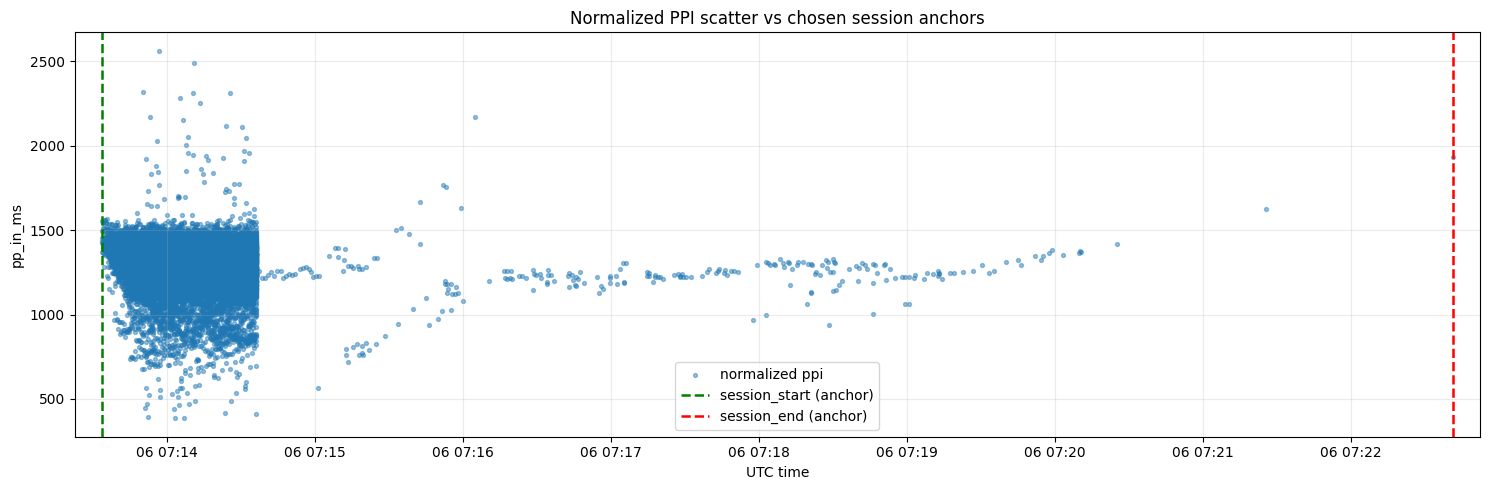

In [130]:
def plot_normalized_ppi_session_window(
    dfn: pd.DataFrame,
    session_start: pd.Timestamp,
    session_end: pd.Timestamp,
    skip: int = 0,
    take: int | None = None,  # None => full session
    y_col: str = 'pp_in_ms',
    quality_col: str = 'sample_quality_tier',
    max_points: int = 12000,  # visual downsample cap
):
    x = dfn.sort_values('ts_utc').copy()
    if take is not None:
        x = x.iloc[skip:skip+take].copy()
    elif skip > 0:
        x = x.iloc[skip:].copy()

    if x.empty:
        print('Empty slice')
        return x

    if y_col not in x.columns:
        y_col = 'ppInMs' if 'ppInMs' in x.columns else y_col

    # Coverage diagnostics against the chosen anchors
    inside = (x['ts_utc'] >= session_start) & (x['ts_utc'] <= session_end)
    inside_ratio = float(inside.mean())
    print('rows_plotted:', len(x))
    print('inside_ratio_in_anchor_window:', inside_ratio)
    print('ts_min:', x['ts_utc'].min(), 'ts_max:', x['ts_utc'].max())
    print('anchor_start:', session_start, 'anchor_end:', session_end)

    # Downsample only for rendering performance, preserving timeline shape
    if len(x) > max_points:
        step = max(1, len(x) // max_points)
        xp = x.iloc[::step].copy()
    else:
        xp = x

    plt.figure(figsize=(15,5))

    if quality_col in xp.columns:
        palette = {'low':'tab:red', 'medium':'tab:orange', 'high':'tab:green'}
        for tier, g in xp.groupby(quality_col, dropna=False):
            plt.scatter(g['ts_utc'], g[y_col], s=8, alpha=0.65, color=palette.get(str(tier), 'tab:gray'), label=f'quality={tier}')
    else:
        plt.scatter(xp['ts_utc'], xp[y_col], s=8, alpha=0.45, color='tab:blue', label='normalized ppi')

    plt.axvline(session_start, color='green', linestyle='--', linewidth=1.8, label='session_start (anchor)')
    plt.axvline(session_end, color='red', linestyle='--', linewidth=1.8, label='session_end (anchor)')

    # Lock visible window to chosen anchors (+small margin), so scaling is never misleading
    span = session_end - session_start
    pad = span * 0.02
    plt.xlim(session_start - pad, session_end + pad)

    plt.title('Normalized PPI scatter vs chosen session anchors')
    plt.xlabel('UTC time')
    plt.ylabel(y_col)
    plt.grid(alpha=0.25)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

    return x


# Guard: do not draw misleading canonical plot from stale normalized cache
if 'is_new_cumulative' in globals() and not is_new_cumulative:
    raise RuntimeError('Normalized cache is not L2 cumulative. Refresh local cache from server before plotting this chart.')

# Use the exact anchors from time_alignment_report (the same basis used by normalization).
# By default plot FULL session (take=None), not only first rows.
_ = plot_normalized_ppi_session_window(
    dfn=dfn,
    session_start=session_start_norm,
    session_end=session_end_norm,
    skip=0,
    take=None,
)
